#Section 1: Project Overview
##Explainable Machine Learning for Business Customer Churn Prediction
### Comparing Financial and Service-Engagement Factors in Telecommunications Customer Churn

A Bulgarian telecommunications operator wants to know which of its **business**
customers (small, medium and large companies) are at risk of leaving for a
competitor. This notebook builds an explainable churn-prediction pipeline and
uses it to answer one specific question about *what kind* of customer
information carries predictive value.

**What this project is:** an empirical comparison of two families of customer
attributes, evaluated with three models, under proper imbalanced-classification
methodology, with model explanations.

**What this project is not:** a claim of novelty. This dataset was published
with existing research attached to it. Applying machine learning to it is not
itself a contribution. Our contribution is the *controlled feature-group
comparison* plus honest reporting of how much signal actually exists.

## Section 2: Research Questions


**RQ1 (primary).** Are financial characteristics or service-engagement
characteristics more useful for predicting business customer churn?

**RQ2.** Does combining both families improve prediction over the better
family alone?

**RQ3.** Which individual attributes contribute most to the model's
predictions, and what do they mean for retention strategy?

### Method for answering RQ1 and RQ2
Three feature configurations (Financial / Engagement / Combined) x three models
(Logistic Regression / Random Forest / XGBoost) = 9 experiments.

**Important design decision made in advance:** we will *not* decide RQ1 from a
single train/test split. We will use repeated stratified cross-validation and
compare feature groups with paired significance tests across matched folds.
Reason: with only 549 churners, fold-to-fold variation is large, and a
single-split comparison would let random noise decide the research question.

## Section 3: Dataset

**Customer Churn Dataset — business customers of a leading Bulgarian telecom
operator.** Published 11 November 2024 by Dimitar Tokmakov
(Plovdivski universitet Paisij Hilendarski).
Source: https://data.mendeley.com/datasets/nrb55gr66h/1
DOI: 10.17632/nrb55gr66h.1

File used: `Baza_customer_Telecom_v2.csv` (single file, so no file-selection
question arises).

**Note on the published description.** The Mendeley page states 8,454 instances
and 14 attributes plus 1 target. The actual file contains **8,453 rows and 14
columns total (13 features + 1 target)**. It also describes "CRM PID" and
"Value Segment" as separate attributes, but the file merges them into one
column, and it contains an undocumented column, `EffectiveSegment`.
We report what is in the file, and flag the discrepancy rather than repeating
the published figures.

## Section 4 : Data Loading

- **Cell 1** — imports, global random seed, display settings. Everything
  downstream depends on `RANDOM_STATE`, set once here.
- **Cell 2** — load the raw CSV and print column names using `repr()`. We use
  `repr()` deliberately: it exposes invisible whitespace, and this file has a
  trailing space in one header.
- **Cell 3** — strip whitespace from headers, then preview the data.

In [2]:
# ===== CODE CELL 1 =====
# Imports, reproducibility seed, and display settings.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)
print("RANDOM_STATE =", RANDOM_STATE)

pandas : 2.2.3
numpy  : 2.1.3
RANDOM_STATE = 42


In [4]:
# ===== CODE CELL 2 =====
# Load the raw file. Print column names with repr() to reveal hidden whitespace.
DATA_PATH = "data/Baza customer Telecom v2.csv"   # adjust to your local path
raw = pd.read_csv(DATA_PATH)

print("Raw shape (rows, columns):", raw.shape)
print("\nColumn names exactly as stored in the file:")
for i, c in enumerate(raw.columns):
    print(f"  {i:2d}  {c!r}")

Raw shape (rows, columns): (8453, 14)

Column names exactly as stored in the file:
   0  'PID'
   1  'CRM_PID_Value_Segment'
   2  'EffectiveSegment'
   3  'Billing_ZIP'
   4  'KA_name'
   5  'Active_subscribers'
   6  'Not_Active_subscribers'
   7  'Suspended_subscribers'
   8  'Total_SUBs'
   9  'AvgMobileRevenue '
  10  'AvgFIXRevenue'
  11  'TotalRevenue'
  12  'ARPU'
  13  'CHURN'


In [5]:
# ===== CODE CELL 3 =====
# Fix the header whitespace found in Cell 2, then preview.
raw.columns = [c.strip() for c in raw.columns]
print("Cleaned column names:", list(raw.columns))
print("\nFirst 5 rows:")
display(raw.head())

Cleaned column names: ['PID', 'CRM_PID_Value_Segment', 'EffectiveSegment', 'Billing_ZIP', 'KA_name', 'Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers', 'Total_SUBs', 'AvgMobileRevenue', 'AvgFIXRevenue', 'TotalRevenue', 'ARPU', 'CHURN']

First 5 rows:


,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,NaN,NaN,2,40.17,0.0,40.17,NaN,No
1,126145737,Bronze,SOHO,6400.0,VM,3,NaN,NaN,3,40.17,0.0,40.17,13.39,No
2,123506355,Bronze,SOHO,6000.0,DI,2,3.0,NaN,5,40.17,0.0,40.17,20.09,No
3,112595585,Bronze,SOHO,4400.0,MT,1,2.0,NaN,3,40.17,0.0,40.17,40.17,No
4,115097935,Iron,SOHO,4000.0,AD,2,1.0,NaN,3,40.17,0.0,40.17,20.09,No


## Section 5:  Data Understanding

We inspect the real structure before deciding anything. No column names or
types are assumed from the dataset description.

- **Cell 4** — dtype, missing count, missing %, and cardinality for all 14
  columns in one table.
- **Cell 5** — duplicate detection, including a check on the ID column.
- **Cell 6** — value counts for the target and all categorical columns. This is
  where data-entry inconsistencies surface.
- **Cell 7** — descriptive statistics for numeric columns, plus an audit for
  zeros and impossible negative values.
- **Cell 8** — the summary overview table.

In [6]:
# ===== CODE CELL 4 =====
# One table: dtype, missingness and cardinality for every column.
info = pd.DataFrame({
    "dtype":       raw.dtypes.astype(str),
    "n_missing":   raw.isna().sum(),
    "pct_missing": (raw.isna().mean() * 100).round(2),
    "n_unique":    raw.nunique(),
})
display(info)

,dtype,n_missing,pct_missing,n_unique
PID,object,0,0.00,8436
CRM_PID_Value_Segment,object,5,0.06,9
EffectiveSegment,object,0,0.00,6
Billing_ZIP,float64,2,0.02,456
KA_name,object,0,0.00,12
Active_subscribers,int64,0,0.00,61
Not_Active_subscribers,float64,4149,49.08,60
Suspended_subscribers,float64,8101,95.84,13
Total_SUBs,int64,0,0.00,89
AvgMobileRevenue,float64,0,0.00,2150


In [9]:
# ===== CODE CELL 5 =====
# Duplicate detection. Also check whether the ID column is trustworthy.

print("Exact duplicate rows (all 14 columns):", raw.duplicated().sum())
print("Duplicate rows ignoring PID          :",
      raw.duplicated(subset=[c for c in raw.columns if c != "PID"]).sum())

sci = raw["PID"].astype(str).str.contains(r"E\+", regex=True, na=False)
print("\nPIDs stored in scientific notation   :", sci.sum())
print("Distinct PID strings                 :", raw["PID"].nunique(), "of", len(raw), "rows")

Exact duplicate rows (all 14 columns): 0
Duplicate rows ignoring PID          : 20

PIDs stored in scientific notation   : 26
Distinct PID strings                 : 8436 of 8453 rows


For interview (if needed) : There are zero true duplicates. But 26 PIDs were exported as 1.21E+12, losing precision and collapsing distinct customers onto identical ID strings. So PID.nunique() of 8,436 is a false duplicate signal caused by a formatting bug, not repeated customers. The 20 rows that match on everything except PID are plausibly genuine distinct micro-accounts with identical profiles. We delete nothing.

In [10]:
# ===== CODE CELL 6 =====
# Value counts for the target and every categorical column.
for col in ["CHURN", "CRM_PID_Value_Segment", "EffectiveSegment", "KA_name"]:
    print(f"\n--- {col} ---")
    print(raw[col].value_counts(dropna=False).to_string())


--- CHURN ---
CHURN
No     7904
Yes     549

--- CRM_PID_Value_Segment ---
CRM_PID_Value_Segment
Bronze      3820
Silver      2039
Gold        1453
Platinum     537
SME          284
Iron         246
SE            41
Lead          27
NaN            5
Sliver         1

--- EffectiveSegment ---
EffectiveSegment
SOHO     6301
VSE      1795
SME       284
SE         42
Other      29
LE          2

--- KA_name ---
KA_name
VM                   769
RJ                   751
Tatiana Trifonova    719
Ginka Vachkova       715
Jenia Gogova         714
MT                   710
AD?                  707
VU                   696
DI                   695
AD                   694
VT                   681
Daniela Stefanova    602


In [11]:
# ===== CODE CELL 7 =====
# Descriptive statistics + audit for zeros and impossible negative values.
NUMERIC_RAW = ["Active_subscribers", "Not_Active_subscribers", "Suspended_subscribers",
               "Total_SUBs", "AvgMobileRevenue", "AvgFIXRevenue", "TotalRevenue", "ARPU"]

display(raw[NUMERIC_RAW].describe().T.round(2))

print("Zero / negative audit:")
for c in NUMERIC_RAW:
    s = raw[c]
    print(f"  {c:24s} min={s.min():>8.2f}  zeros={int((s==0).sum()):>5}  negatives={int((s<0).sum()):>4}")

,count,mean,std,min,25%,50%,75%,max
Active_subscribers,8453.0,7.77,6.68,1.00,4.00,6.00,10.00,110.00
Not_Active_subscribers,4304.0,4.16,9.46,1.00,1.00,2.00,4.00,214.00
Suspended_subscribers,352.0,1.58,1.98,1.00,1.00,1.00,1.00,22.00
Total_SUBs,8453.0,9.96,10.25,1.00,5.00,7.00,12.00,235.00
AvgMobileRevenue,8453.0,148.01,102.57,0.00,71.50,113.17,191.17,499.83
AvgFIXRevenue,8453.0,0.82,11.74,0.00,0.00,0.00,0.00,480.50
TotalRevenue,8453.0,148.83,103.25,4.67,71.83,113.67,192.33,499.83
ARPU,8452.0,24.44,22.82,0.00,14.07,19.31,27.26,462.83


Zero / negative audit:
  Active_subscribers       min=    1.00  zeros=    0  negatives=   0
  Not_Active_subscribers   min=    1.00  zeros=    0  negatives=   0
  Suspended_subscribers    min=    1.00  zeros=    0  negatives=   0
  Total_SUBs               min=    1.00  zeros=    0  negatives=   0
  AvgMobileRevenue         min=    0.00  zeros=    1  negatives=   0
  AvgFIXRevenue            min=    0.00  zeros= 8331  negatives=   0
  TotalRevenue             min=    4.67  zeros=    0  negatives=   0
  ARPU                     min=    0.00  zeros=    1  negatives=   0


The minimum of Not_Active_subscribers and Suspended_subscribers is 1.00, with zero recorded zeros. A count column that never records zero, combined with heavy blankness, is strong evidence the blanks are the zeros.

AvgFIXRevenue is 0 for 8,331 of 8,453 customers (98.6%). Only 122 customers buy fixed-line services. This column is nearly constant.

In [12]:
# ===== CODE CELL 8 =====
# The dataset overview table (real values only).
n_churn = int((raw["CHURN"] == "Yes").sum())
n_stay  = int((raw["CHURN"] == "No").sum())

overview = pd.DataFrame({
    "Property": ["Number of customers", "Number of columns in file", "Feature columns",
                 "Target variable", "Churned customers", "Non-churned customers",
                 "Churn rate", "Class imbalance ratio (No:Yes)"],
    "Value": [len(raw), raw.shape[1], raw.shape[1] - 1, "CHURN (Yes/No)",
              n_churn, n_stay, f"{n_churn/len(raw)*100:.2f}%", f"{n_stay/n_churn:.1f} : 1"],
})
display(overview)

,Property,Value
0,Number of customers,8453
1,Number of columns in file,14
2,Feature columns,13
3,Target variable,CHURN (Yes/No)
4,Churned customers,549
5,Non-churned customers,7904
6,Churn rate,6.49%
7,Class imbalance ratio (No:Yes),14.4 : 1


## Section 6 : Structural Integrity Checks (arithmetic identities)

This section is not standard in tutorial notebooks, and it is the single most
useful thing we do before modelling. We test whether columns are exact
arithmetic functions of other columns.

**Cell 9** tests three hypotheses. The results determine:
1. how to impute the blanks (evidence, not guesswork),
2. which columns are perfectly collinear (this breaks linear-model
   coefficient interpretation, which our explainability section depends on),
3. whether ARPU is genuinely a "financial" feature — because if ARPU is
   computed using a subscriber count, then it secretly carries engagement
   information and contaminates the entire RQ1 comparison.

In [13]:
# ===== CODE CELL 9 =====
# Test whether columns are exact arithmetic functions of other columns.
n = len(raw)

print("IDENTITY 1: TotalRevenue == AvgMobileRevenue + AvgFIXRevenue")
d1 = (raw["TotalRevenue"] - (raw["AvgMobileRevenue"] + raw["AvgFIXRevenue"])).abs()
print(f"   matches within 0.01 : {int((d1<=0.01).sum())} / {n}  ({(d1<=0.01).mean()*100:.2f}%)")

print("\nIDENTITY 2: Total_SUBs == Active + Not_Active + Suspended   (blanks treated as 0)")
na0 = raw["Not_Active_subscribers"].fillna(0)
su0 = raw["Suspended_subscribers"].fillna(0)
m2 = (raw["Active_subscribers"] + na0 + su0) == raw["Total_SUBs"]
print(f"   matches            : {int(m2.sum())} / {n}  ({m2.mean()*100:.2f}%)")
m2b = (raw["Active_subscribers"] + na0) == raw["Total_SUBs"]
print(f"   without Suspended  : {int(m2b.sum())} / {n}  ({m2b.mean()*100:.2f}%)   <- blanks are zeros")

print("\nIDENTITY 3: what is ARPU dividing by?")
for denom in ["Active_subscribers", "Total_SUBs"]:
    calc = (raw["TotalRevenue"] / raw[denom]).round(2)
    ok = (calc - raw["ARPU"]).abs() <= 0.02
    print(f"   ARPU == TotalRevenue / {denom:20s}: {int(ok.sum())} / {n}  ({ok.mean()*100:.2f}%)")

IDENTITY 1: TotalRevenue == AvgMobileRevenue + AvgFIXRevenue
   matches within 0.01 : 8453 / 8453  (100.00%)

IDENTITY 2: Total_SUBs == Active + Not_Active + Suspended   (blanks treated as 0)
   matches            : 8453 / 8453  (100.00%)
   without Suspended  : 8101 / 8453  (95.84%)   <- blanks are zeros

IDENTITY 3: what is ARPU dividing by?
   ARPU == TotalRevenue / Active_subscribers  : 8330 / 8453  (98.54%)
   ARPU == TotalRevenue / Total_SUBs          : 3965 / 8453  (46.91%)


## Section 7: Data Cleaning

Every decision below follows from evidence gathered in Cells 4-9. **No rows are
deleted.**

- **Cell 10** applies the cleaning:
  1. Drop `PID` — a pure identifier with no predictive content, and corrupted
     in 26 rows anyway (Cell 5).
  2. Fill `Not_Active_subscribers` and `Suspended_subscribers` blanks with 0 —
     justified by Identity 2 closing at exactly 100% (Cell 9), not by
     convenience.
  3. Recompute the 1 missing ARPU with its own formula from Identity 3. Better
     than mean-imputing a value we can derive exactly.
  4. Merge the `Sliver` -> `Silver` typo and label the 5 missing segments as
     `Unknown` (an explicit category, so we keep those 5 customers).
  5. Encode the target: No -> 0, Yes -> 1.

  `Billing_ZIP`'s 2 missing values are left as-is; that column is excluded
  from modelling anyway (see Section 10).

- **Cell 11** re-asserts the identities *after* cleaning. If cleaning silently
  broke an assumption, this cell fails loudly instead of poisoning the results.

In [14]:
# ===== CODE CELL 10 =====
# Apply cleaning decisions. No rows are removed.
df = raw.copy()

# 1. Drop the identifier column
df = df.drop(columns=["PID"])

# 2. Blanks are zeros -- proven by Identity 2 in Cell 9
df["Not_Active_subscribers"] = df["Not_Active_subscribers"].fillna(0).astype(int)
df["Suspended_subscribers"]  = df["Suspended_subscribers"].fillna(0).astype(int)

# 3. Recompute the single missing ARPU using Identity 3 from Cell 9
n_arpu_fixed = int(df["ARPU"].isna().sum())
df["ARPU"] = df["ARPU"].fillna(df["TotalRevenue"] / df["Active_subscribers"]).round(2)

# 4. Fix the categorical typo; keep the 5 unlabelled customers as 'Unknown'
df["Value_Segment"] = (df["CRM_PID_Value_Segment"]
                       .replace({"Sliver": "Silver"})
                       .fillna("Unknown"))
df = df.drop(columns=["CRM_PID_Value_Segment"])

# 5. Binary target
df["CHURN_FLAG"] = (df["CHURN"] == "Yes").astype(int)

print("Rows retained            :", len(df), "of", len(raw), "-> no rows deleted")
print("ARPU values recomputed   :", n_arpu_fixed)
print("Remaining missing values :")
print(df.isna().sum()[df.isna().sum() > 0].to_string())

Rows retained            : 8453 of 8453 -> no rows deleted
ARPU values recomputed   : 1
Remaining missing values :
Billing_ZIP    2


In [15]:
# ===== CODE CELL 11 =====
# Re-assert the structural identities AFTER cleaning. Fail loudly, not silently.
assert (df["Active_subscribers"] + df["Not_Active_subscribers"]
        + df["Suspended_subscribers"] == df["Total_SUBs"]).all()
assert df["ARPU"].isna().sum() == 0
assert df["CHURN_FLAG"].isin([0, 1]).all()
assert len(df) == len(raw)

print("All post-cleaning assertions passed.")
print("\nValue_Segment after typo merge:")
print(df["Value_Segment"].value_counts().to_string())

All post-cleaning assertions passed.

Value_Segment after typo merge:
Value_Segment
Bronze      3820
Silver      2040
Gold        1453
Platinum     537
SME          284
Iron         246
SE            41
Lead          27
Unknown        5


## Section 8: Target and Class Imbalance

- **Cell 12** quantifies the imbalance and computes the accuracy of a model
  that predicts "nobody churns". This number is the reason accuracy is banned
  as our primary metric.
- **Cell 13** visualises the class distribution.

In [16]:
# ===== CODE CELL 12 =====
# Quantify the imbalance, and expose why accuracy is a misleading metric here.
counts = df["CHURN_FLAG"].value_counts().sort_index()
pcts   = df["CHURN_FLAG"].value_counts(normalize=True).sort_index() * 100

dist = pd.DataFrame({"n": counts, "percent": pcts.round(2)})
dist.index = ["No churn (0)", "Churn (1)"]
display(dist)

print(f"Imbalance ratio     : {counts[0]/counts[1]:.2f} : 1")
print(f"Minority prevalence : {df['CHURN_FLAG'].mean()*100:.2f}%")
print(f"Accuracy of a naive 'nobody churns' model: {(1-df['CHURN_FLAG'].mean())*100:.2f}%")

,n,percent
No churn (0),7904,93.51
Churn (1),549,6.49


Imbalance ratio     : 14.40 : 1
Minority prevalence : 6.49%
Accuracy of a naive 'nobody churns' model: 93.51%


Interpretation : A model that identifies zero churners scores 93.51% accuracy. Any model we build must beat that bar to justify its accuracy figure at all  and beating it says nothing about whether we found any churners. This is why F1, Recall and PR-AUC lead our evaluation. PR-AUC has a meaningful floor here: 0.0649, the churn prevalence.

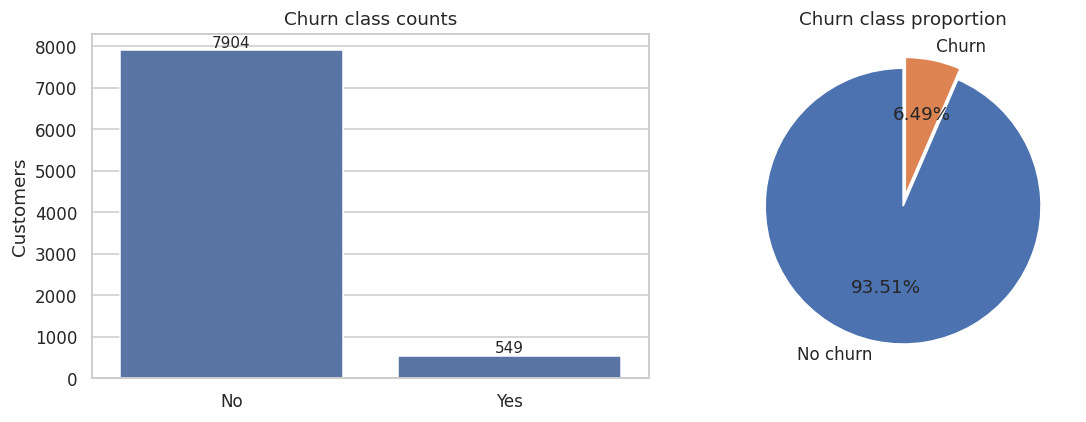

In [17]:
# ===== CODE CELL 13 =====
# Visualise the class distribution.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="CHURN", data=df, order=["No", "Yes"], ax=ax[0])
ax[0].set_title("Churn class counts"); ax[0].set_xlabel(""); ax[0].set_ylabel("Customers")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height())}",
                   (p.get_x() + p.get_width()/2, p.get_height()),
                   ha="center", va="bottom", fontsize=10)

ax[1].pie(counts, labels=["No churn", "Churn"], autopct="%1.2f%%", startangle=90,
          colors=sns.color_palette("deep")[:2], explode=(0, 0.08))
ax[1].set_title("Churn class proportion")

plt.tight_layout(); plt.show()

## Section 9: Exploratory Data Analysis

Seven focused cells, not dozens of plots. Each one is chosen to inform a
specific modelling decision.

- **Cell 14** — churn rate by each categorical column, via a reusable helper.
- **Cell 15** — the value-segment result as a chart, with the overall churn
  rate drawn as a reference line so segment differences are readable.
- **Cell 16** — financial features split by churn (box plots).
- **Cell 17** — engagement features split by churn (box plots).
- **Cell 18** — Spearman correlation heatmap. Spearman rather than Pearson
  because the revenue and subscriber columns are strongly right-skewed.
- **Cell 19** — univariate association strength with churn, ranked and coloured
  by feature group. This is our first honest look at how much signal exists.
- **Cell 20** — the data-leakage probe on `Suspended_subscribers`.

In [18]:
# ===== CODE CELL 14 =====
# Reusable helper: churn rate by category.
def churn_by(col, min_n=1):
    t = df.groupby(col)["CHURN_FLAG"].agg(n="size", churned="sum")
    t["churn_rate_%"] = (t["churned"] / t["n"] * 100).round(2)
    return t[t["n"] >= min_n].sort_values("churn_rate_%", ascending=False)

for col in ["Value_Segment", "EffectiveSegment"]:
    print(f"\n--- Churn rate by {col} ---")
    print(churn_by(col).to_string())

print(f"\nOverall churn rate: {df['CHURN_FLAG'].mean()*100:.2f}%")


--- Churn rate by Value_Segment ---
                  n  churned  churn_rate_%
Value_Segment                             
SME             284       25          8.80
Platinum        537       46          8.57
Gold           1453      117          8.05
Silver         2040      146          7.16
Bronze         3820      205          5.37
Iron            246        9          3.66
SE               41        1          2.44
Lead             27        0          0.00
Unknown           5        0          0.00

--- Churn rate by EffectiveSegment ---
                     n  churned  churn_rate_%
EffectiveSegment                             
VSE               1795      159          8.86
SME                284       25          8.80
Other               29        2          6.90
SOHO              6301      362          5.75
SE                  42        1          2.38
LE                   2        0          0.00

Overall churn rate: 6.49%


Interpretation: there is a monotone gradient across the value tiers — Platinum (8.57%) → Gold (8.05%) → Silver (7.16%) → Bronze (5.37%) → Iron (3.66%). Higher-value business customers churn at roughly 1.6× the rate of low-value ones. This is the clearest single pattern in the dataset, and it is commercially uncomfortable: the customers worth most are the ones leaving most. EffectiveSegment shows the same shape (VSE 8.86% vs SOHO 5.75%). Note the two tiny segments (Lead n=27, LE n=2) show 0% churn — that is small-sample noise, not a finding.

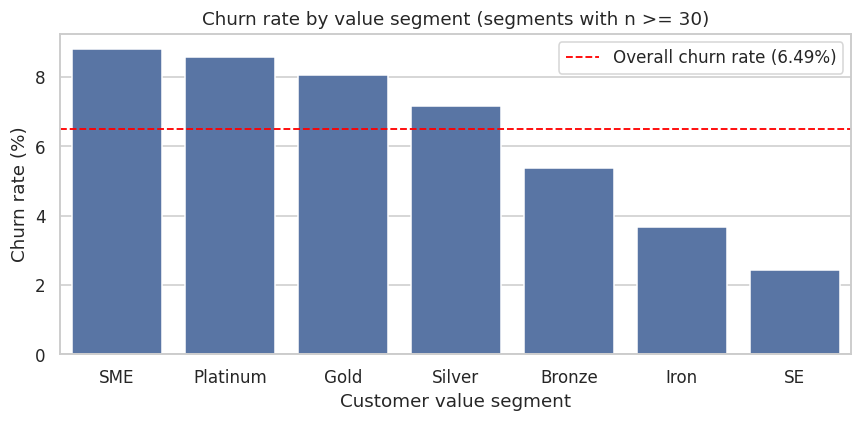

In [19]:
# ===== CODE CELL 15 =====
# Value-segment churn rate, with the overall rate as a reference line.
tab = churn_by("Value_Segment")
tab = tab[tab["n"] >= 30]        # suppress segments too small to interpret

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=tab.index, y=tab["churn_rate_%"], ax=ax)
ax.axhline(df["CHURN_FLAG"].mean() * 100, color="red", ls="--", lw=1.2,
           label="Overall churn rate (6.49%)")
ax.set_ylabel("Churn rate (%)"); ax.set_xlabel("Customer value segment")
ax.set_title("Churn rate by value segment (segments with n >= 30)")
ax.legend(); plt.tight_layout(); plt.show()

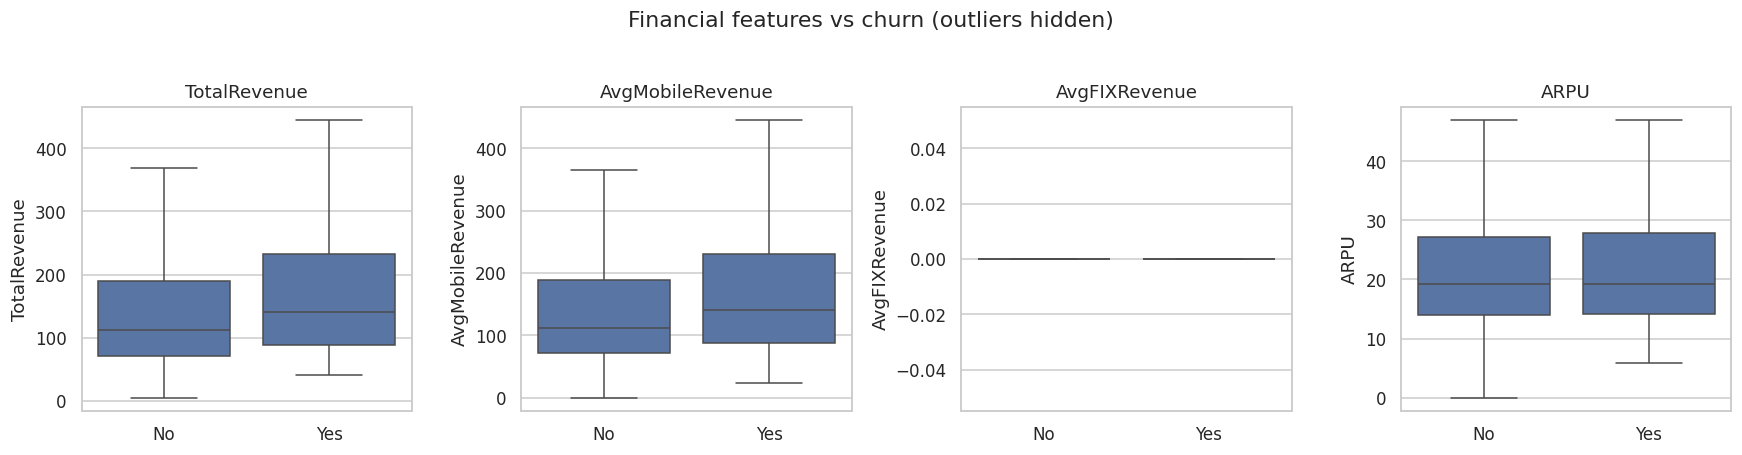

Medians:
       TotalRevenue  AvgMobileRevenue  AvgFIXRevenue   ARPU
CHURN                                                      
No           111.67            111.33            0.0  19.32
Yes          140.17            140.17            0.0  19.23

Means:
       TotalRevenue  AvgMobileRevenue  AvgFIXRevenue  ARPU
CHURN                                                     
No           147.10            146.25           0.85  24.4
Yes          173.81            173.33           0.48  25.0


In [20]:
# ===== CODE CELL 16 =====
# Financial features split by churn status.
FIN_PLOT = ["TotalRevenue", "AvgMobileRevenue", "AvgFIXRevenue", "ARPU"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for a, c in zip(axes, FIN_PLOT):
    sns.boxplot(x="CHURN", y=c, data=df, order=["No", "Yes"], ax=a, showfliers=False)
    a.set_title(c); a.set_xlabel("")
plt.suptitle("Financial features vs churn (outliers hidden)", y=1.03)
plt.tight_layout(); plt.show()

print("Medians:"); print(df.groupby("CHURN")[FIN_PLOT].median().round(2).to_string())
print("\nMeans:");  print(df.groupby("CHURN")[FIN_PLOT].mean().round(2).to_string())

Interpretation: churners have a ~26% higher median total revenue (140.17 vs 111.67) — consistent with the value-segment gradient. But ARPU is essentially identical between the groups (median 19.23 vs 19.32). That is a meaningful distinction: it's account-level revenue that separates churners, not per-subscriber spend. Larger accounts churn more; expensive-per-line accounts do not. AvgFIXRevenue is flat at 0 for both, as expected from Cell 7.

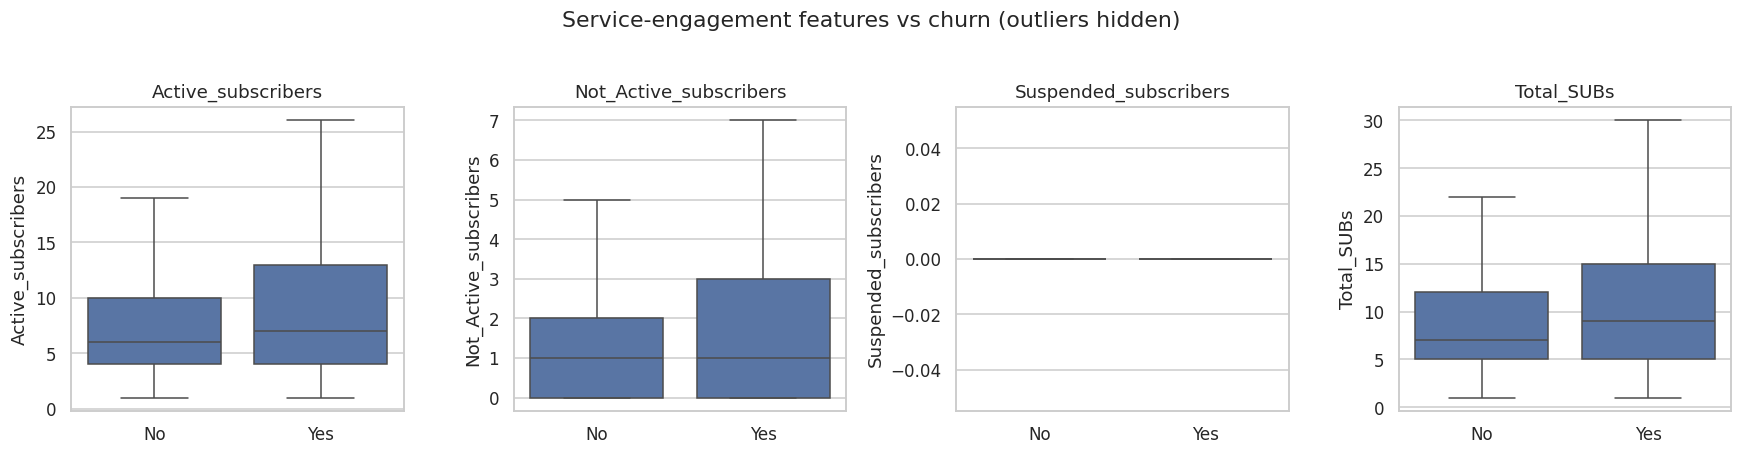

Medians:
       Active_subscribers  Not_Active_subscribers  Suspended_subscribers  Total_SUBs
CHURN                                                                               
No                    6.0                     1.0                    0.0         7.0
Yes                   7.0                     1.0                    0.0         9.0

Means:
       Active_subscribers  Not_Active_subscribers  Suspended_subscribers  Total_SUBs
CHURN                                                                               
No                   7.67                    2.11                   0.06        9.84
Yes                  9.34                    2.30                   0.09       11.72


In [21]:
# ===== CODE CELL 17 =====
# Service-engagement features split by churn status.
ENG_PLOT = ["Active_subscribers", "Not_Active_subscribers",
            "Suspended_subscribers", "Total_SUBs"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for a, c in zip(axes, ENG_PLOT):
    sns.boxplot(x="CHURN", y=c, data=df, order=["No", "Yes"], ax=a, showfliers=False)
    a.set_title(c); a.set_xlabel("")
plt.suptitle("Service-engagement features vs churn (outliers hidden)", y=1.03)
plt.tight_layout(); plt.show()

print("Medians:"); print(df.groupby("CHURN")[ENG_PLOT].median().round(2).to_string())
print("\nMeans:");  print(df.groupby("CHURN")[ENG_PLOT].mean().round(2).to_string())

Interpretation: churners run larger accounts (median 9 vs 7 total subscribers) — the same account-size story as the revenue features, which is unsurprising given revenue and subscriber counts are related. The disengagement signals I expected to matter most are the weakest: Not_Active medians are identical (1.0 vs 1.0), and Suspended medians are both 0. The intuitive hypothesis that inactive lines predict leaving gets essentially no support here.

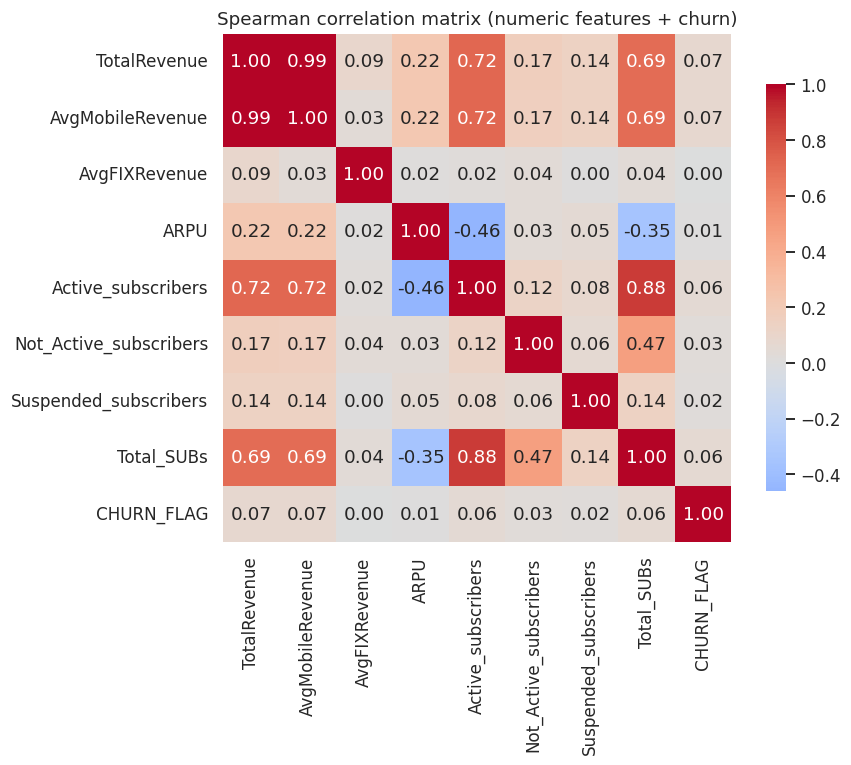

Correlation with churn, ranked:
AvgMobileRevenue          0.0721
TotalRevenue              0.0708
Total_SUBs                0.0599
Active_subscribers        0.0551
Not_Active_subscribers    0.0266
Suspended_subscribers     0.0198
ARPU                      0.0057
AvgFIXRevenue             0.0003


In [22]:
# ===== CODE CELL 18 =====
# Spearman correlation heatmap (rank-based: revenue/subscriber columns are skewed).
NUM_ALL = FIN_PLOT + ENG_PLOT
corr = df[NUM_ALL + ["CHURN_FLAG"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Spearman correlation matrix (numeric features + churn)")
plt.tight_layout(); plt.show()

print("Correlation with churn, ranked:")
print(corr["CHURN_FLAG"].drop("CHURN_FLAG").sort_values(ascending=False).round(4).to_string())

what the heatmap shows off the churn row: TotalRevenue–AvgMobileRevenue and Total_SUBs–Active_subscribers are near-perfectly correlated, exactly as Cell 9's identities predicted.

,pearson,spearman,abs_pearson,group
AvgMobileRevenue,0.0651,0.0721,0.0651,Financial
TotalRevenue,0.0637,0.0708,0.0637,Financial
Active_subscribers,0.0617,0.0551,0.0617,Engagement
Total_SUBs,0.0453,0.0599,0.0453,Engagement
Suspended_subscribers,0.0112,0.0198,0.0112,Engagement
AvgFIXRevenue,-0.0077,0.0003,0.0077,Financial
Not_Active_subscribers,0.0066,0.0266,0.0066,Engagement
ARPU,0.0065,0.0057,0.0065,Financial


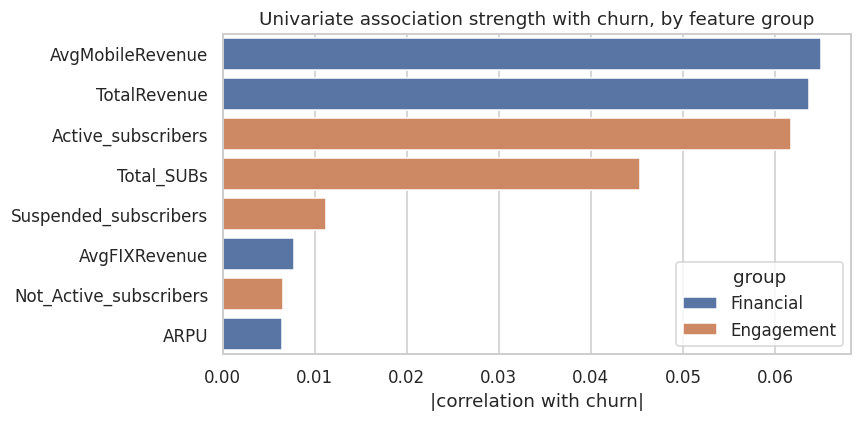

Strongest single association: AvgMobileRevenue at r = +0.0651


In [23]:
# ===== CODE CELL 19 =====
# Rank univariate association strength with churn, coloured by feature group.
sig = pd.DataFrame({
    "pearson":  [df[c].corr(df["CHURN_FLAG"]) for c in NUM_ALL],
    "spearman": [df[c].corr(df["CHURN_FLAG"], method="spearman") for c in NUM_ALL],
}, index=NUM_ALL)
sig["abs_pearson"] = sig["pearson"].abs()
sig["group"] = ["Financial"] * 4 + ["Engagement"] * 4
sig = sig.sort_values("abs_pearson", ascending=False)
display(sig.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=sig["abs_pearson"], y=sig.index, hue=sig["group"], dodge=False, ax=ax)
ax.set_xlabel("|correlation with churn|"); ax.set_ylabel("")
ax.set_title("Univariate association strength with churn, by feature group")
plt.tight_layout(); plt.show()

print(f"Strongest single association: {sig.index[0]} at r = {sig['pearson'].iloc[0]:+.4f}")

The strongest association anywhere in the dataset is r = +0.065. That is very weak — under 0.5% of variance explained. Write this interpretation into the notebook now, before modelling, because it sets honest expectations: no model built on these features can be expected to separate churners well. When Part 2 returns ROC-AUC around 0.57, that will be a direct consequence of what this cell already shows, not a bug in the modelling.

Note the ranking also gives an early, tentative hint on RQ1: the top two features are both Financial. Part 2 tests whether that survives proper evaluation.

In [24]:
# ===== CODE CELL 20 =====
# Leakage probe: is 'Suspended_subscribers' a symptom of churn rather than a predictor?
probe = df.assign(
    has_suspended=(df["Suspended_subscribers"] > 0).astype(int),
    has_inactive =(df["Not_Active_subscribers"] > 0).astype(int),
    has_fixed    =(df["AvgFIXRevenue"] > 0).astype(int),
)

for flag in ["has_suspended", "has_inactive", "has_fixed"]:
    t = probe.groupby(flag)["CHURN_FLAG"].agg(n="size", churned="sum")
    t["churn_rate_%"] = (t["churned"] / t["n"] * 100).round(2)
    print(f"\n--- {flag} ---"); print(t.to_string())

n_churn_susp = int(probe.loc[probe["has_suspended"] == 1, "CHURN_FLAG"].sum())
print(f"\nChurners with any suspended subscriber: {n_churn_susp} of {int(df['CHURN_FLAG'].sum())}")


--- has_suspended ---
                  n  churned  churn_rate_%
has_suspended                             
0              8101      518          6.39
1               352       31          8.81

--- has_inactive ---
                 n  churned  churn_rate_%
has_inactive                             
0             4149      249          6.00
1             4304      300          6.97

--- has_fixed ---
              n  churned  churn_rate_%
has_fixed                             
0          8331      541          6.49
1           122        8          6.56

Churners with any suspended subscriber: 31 of 549


## Section 10: Feature Group Definition

The central experiment. Three feature configurations, built from the actual
columns confirmed in Part 1.

- **Cell 21** defines the groups explicitly as Python lists. Membership is
  argued per column in the markdown below, not assigned automatically.
- **Cell 22** records the leakage and exclusion audit as a table, so the
  reasoning is visible in the notebook rather than buried in prose.

### Group 1 — Financial (5 features)
| Feature | Why it is financial |
|---|---|
| `TotalRevenue` | Total monthly billing for the account |
| `AvgMobileRevenue` | Revenue from mobile services |
| `AvgFIXRevenue` | Revenue from fixed-line services |
| `ARPU` | Average revenue per user *(hybrid — see below)* |
| `Value_Segment` | The operator's own customer-value tier |

### Group 2 — Service-Engagement (4 features)
| Feature | Why it is engagement |
|---|---|
| `Active_subscribers` | Live service lines |
| `Not_Active_subscribers` | Dormant lines — disengagement signal |
| `Suspended_subscribers` | Suspended lines in the last 6 months |
| `Total_SUBs` | Total lines on the account |

### Group 3 — Combined (9 features)
The union of the two.

### Excluded from all three groups
`PID` (identifier), `Billing_ZIP` (456 levels; geography), `KA_name`
(account-manager PII, and `AD` vs `AD?` is unresolvable), `EffectiveSegment`
(firm-size class). None of these belong to either research family, so including
them would confound RQ1. They are excluded *by design*, not because they are
useless.

### The ARPU problem, stated openly
Cell 9 proved `ARPU = TotalRevenue / Active_subscribers`. So a feature the
dataset labels as financial has an *engagement* variable in its denominator.
This structurally contaminates the comparison. We keep ARPU in the Financial
group (that is how the source defines it) and then **test its influence
directly in Cell 27** rather than assuming it does not matter.

In [25]:
# ===== CODE CELL 21 =====
# Define the three feature configurations explicitly.
FINANCIAL_NUM = ["TotalRevenue", "AvgMobileRevenue", "AvgFIXRevenue", "ARPU"]
FINANCIAL_CAT = ["Value_Segment"]

ENGAGEMENT_NUM = ["Active_subscribers", "Not_Active_subscribers",
                  "Suspended_subscribers", "Total_SUBs"]
ENGAGEMENT_CAT = []

EXCLUDED = ["PID", "Billing_ZIP", "KA_name", "EffectiveSegment", "CHURN"]

FEATURE_GROUPS = {
    "Financial":  (FINANCIAL_NUM, FINANCIAL_CAT),
    "Engagement": (ENGAGEMENT_NUM, ENGAGEMENT_CAT),
    "Combined":   (FINANCIAL_NUM + ENGAGEMENT_NUM, FINANCIAL_CAT),
}

for g, (nums, cats) in FEATURE_GROUPS.items():
    print(f"{g:11s} numeric={len(nums)} categorical={len(cats)}  -> {nums + cats}")
print("\nExcluded from all experiments:", EXCLUDED)

Financial   numeric=4 categorical=1  -> ['TotalRevenue', 'AvgMobileRevenue', 'AvgFIXRevenue', 'ARPU', 'Value_Segment']
Engagement  numeric=4 categorical=0  -> ['Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers', 'Total_SUBs']
Combined    numeric=8 categorical=1  -> ['TotalRevenue', 'AvgMobileRevenue', 'AvgFIXRevenue', 'ARPU', 'Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers', 'Total_SUBs', 'Value_Segment']

Excluded from all experiments: ['PID', 'Billing_ZIP', 'KA_name', 'EffectiveSegment', 'CHURN']


Verified: Financial 4+1, Engagement 4+0, Combined 8+1.

In [26]:
# ===== CODE CELL 22 =====
# Record the leakage / exclusion audit in the notebook itself.
audit = pd.DataFrame([
 ["PID", "Identifier", "Dropped", "Row identifier; 26 values corrupted to scientific notation"],
 ["Billing_ZIP", "Other", "Excluded", "456 levels; geography belongs to neither research group"],
 ["KA_name", "Other", "Excluded", "Account-manager PII; 'AD' vs 'AD?' unresolvable"],
 ["EffectiveSegment", "Other", "Excluded", "Firm-size class; belongs to neither research group"],
 ["Suspended_subscribers", "Engagement", "KEPT", "Leakage probe (Cell 20): only 31/549 churners; 6.39%->8.81% lift"],
 ["TotalRevenue", "Financial", "KEPT", "Exact sum of components (Identity 1) - collinearity noted"],
 ["Total_SUBs", "Engagement", "KEPT", "Exact sum of components (Identity 2) - collinearity noted"],
 ["ARPU", "Financial", "KEPT + tested", "Hybrid: divides by Active_subscribers (Identity 3)"],
], columns=["Column", "Classification", "Decision", "Reason"])
display(audit)

,Column,Classification,Decision,Reason
0,PID,Identifier,Dropped,Row identifier; 26 values corrupted to scienti...
1,Billing_ZIP,Other,Excluded,456 levels; geography belongs to neither resea...
2,KA_name,Other,Excluded,Account-manager PII; 'AD' vs 'AD?' unresolvable
3,EffectiveSegment,Other,Excluded,Firm-size class; belongs to neither research g...
4,Suspended_subscribers,Engagement,KEPT,Leakage probe (Cell 20): only 31/549 churners;...
5,TotalRevenue,Financial,KEPT,Exact sum of components (Identity 1) - colline...
6,Total_SUBs,Engagement,KEPT,Exact sum of components (Identity 2) - colline...
7,ARPU,Financial,KEPT + tested,Hybrid: divides by Active_subscribers (Identit...


## Section 11: Train/Test Split

**Cell 23** performs a stratified 80/20 split.

Three points of discipline here:
1. `stratify=y` keeps the 6.49% churn rate in both halves. Without it, random
   variation in a 549-positive dataset could meaningfully shift the test-set
   prevalence and make metrics incomparable.
2. `random_state=RANDOM_STATE` for reproducibility.
3. `scale_pos_weight` for XGBoost is computed **from the training set only**.
   Computing it from the full dataset would leak test-set class information
   into model configuration. It is a small leak, but it is still a leak.

The test set is touched exactly once, in Cell 28. Every decision before that
point is made using cross-validation on the training set.

In [27]:
# ===== CODE CELL 23 =====
# Stratified 80/20 split. The test set is not touched again until Cell 28.
from sklearn.model_selection import train_test_split

ALL_FEATURES = sorted(set(FINANCIAL_NUM + FINANCIAL_CAT + ENGAGEMENT_NUM))
X = df[ALL_FEATURES].copy()
y = df["CHURN_FLAG"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows  churn={y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test : {X_test.shape[0]} rows  churn={y_test.sum()} ({y_test.mean()*100:.2f}%)")
print(f"\nStratification check -> train {y_train.mean()*100:.2f}% vs test {y_test.mean()*100:.2f}%")

# Computed from TRAIN ONLY -- using the full dataset here would leak.
SPW = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (from TRAIN only) = {SPW:.2f}")

Train: 6762 rows  churn=439 (6.49%)
Test : 1691 rows  churn=110 (6.51%)

Stratification check -> train 6.49% vs test 6.51%
scale_pos_weight (from TRAIN only) = 14.40


## Section 12: Preprocessing and Models

**Cell 24** defines pipeline builders. The `Pipeline` is not stylistic — it is
what makes the cross-validation in Cell 25 honest. Inside `cross_validate`,
the scaler and encoder are re-fitted on each training fold only, so no
fold's statistics ever leak into its own validation data. Scaling the whole
dataset up-front and then splitting is the most common leakage mistake in
churn notebooks, and using a Pipeline makes it structurally impossible.

### Class imbalance decision
We use **class weighting**, not SMOTE:
- `class_weight="balanced"` for Logistic Regression and Random Forest
- `scale_pos_weight=14.40` for XGBoost

Rationale: it creates no synthetic customers, it composes correctly with
cross-validation (SMOTE inside a plain `Pipeline` is easy to apply to
validation folds by accident), and it is cheap. With 439 training churners,
generating synthetic minority points from such weak features risks
manufacturing structure that isn't there. The test set is never resampled
under either approach.

### Model choice
| Model | Purpose |
|---|---|
| Logistic Regression | Interpretable linear baseline; directly comparable coefficients |
| Random Forest | Captures non-linearity and interactions; built-in importances |
| XGBoost | Strong gradient boosting for tabular data |

Hyperparameters are lightly regularised and fixed, not tuned. With signal this
weak, extensive tuning would mostly fit noise, and the one-day constraint
rules it out.

In [28]:
# ===== CODE CELL 24 =====
# Pipeline builders. Preprocessing lives INSIDE the pipeline to prevent leakage.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier          # Colab: !pip install xgboost if missing

def make_preprocessor(nums, cats):
    steps = [("num", StandardScaler(), nums)]
    if cats:
        steps.append(("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cats))
    return ColumnTransformer(steps, remainder="drop")

def make_models(spw):
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=400, min_samples_leaf=5, max_features="sqrt",
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, scale_pos_weight=spw,
            eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1),
    }

def build_pipeline(model, nums, cats):
    return Pipeline([("prep", make_preprocessor(nums, cats)), ("clf", model)])

print("Pipeline builders defined.")

Pipeline builders defined.


## Section 13: The Nine Experiments (repeated cross-validation)

**Cell 25** runs 3 feature groups x 3 models under 5-fold stratified CV
repeated 5 times = **25 fits per configuration, 225 fits total**, all on the
training set only.

Why repeated CV instead of just reporting test-set numbers? Because Cell 19
showed the strongest univariate signal is r = 0.065. When effects are that
small, the difference between two feature groups can easily be smaller than
the random variation between folds. Reporting a single number per
configuration would present noise as a finding. The **standard deviation
column is as important as the mean** — compare them before believing any gap.

In [29]:
# ===== CODE CELL 25 =====
# 3 feature groups x 3 models, 5-fold CV repeated 5 times, on TRAINING data only.
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

cv_fold_scores = {}
rows = []
for gname, (nums, cats) in FEATURE_GROUPS.items():
    for mname, model in make_models(SPW).items():
        pipe = build_pipeline(model, nums, cats)
        res = cross_validate(pipe, X_train[nums + cats], y_train, cv=cv,
                             scoring=["roc_auc", "average_precision", "f1", "recall"],
                             n_jobs=-1)
        cv_fold_scores[(gname, mname)] = res
        rows.append({
            "Feature Group": gname, "Model": mname,
            "ROC-AUC": res["test_roc_auc"].mean(), "ROC sd": res["test_roc_auc"].std(),
            "PR-AUC": res["test_average_precision"].mean(), "PR sd": res["test_average_precision"].std(),
            "F1": res["test_f1"].mean(), "Recall": res["test_recall"].mean(),
        })

cv_table = pd.DataFrame(rows)
display(cv_table.round(4))
print(f"PR-AUC no-skill floor (train prevalence) = {y_train.mean():.4f}")

,Feature Group,Model,ROC-AUC,ROC sd,PR-AUC,PR sd,F1,Recall
0,Financial,Logistic Regression,0.5724,0.0273,0.0874,0.0120,0.1398,0.5270
1,Financial,Random Forest,0.5267,0.0267,0.0750,0.0076,0.0805,0.0847
2,Financial,XGBoost,0.5372,0.0275,0.0766,0.0081,0.1189,0.2911
3,Engagement,Logistic Regression,0.5646,0.0310,0.0910,0.0134,0.1340,0.3835
4,Engagement,Random Forest,0.4928,0.0198,0.0718,0.0070,0.1013,0.2411
5,Engagement,XGBoost,0.5092,0.0141,0.0765,0.0066,0.1123,0.3467
6,Combined,Logistic Regression,0.5695,0.0284,0.0863,0.0115,0.1385,0.5148
7,Combined,Random Forest,0.5250,0.0295,0.0804,0.0123,0.0677,0.0551
8,Combined,XGBoost,0.5387,0.0246,0.0807,0.0094,0.1234,0.2652


PR-AUC no-skill floor (train prevalence) = 0.0649


####Three things are visible immediately:

####Every ROC-AUC sits between 0.49 and 0.58. Random guessing is 0.50. Even the best configuration recovers very little separability.Every PR-AUC (0.072–0.091) is barely above the 0.0649 no-skill floor. The best model improves on random ranking by roughly 0.026 in PR-AUC. Engagement + Random Forest scores 0.4928 — below random. A model can only land under 0.50 systematically by fitting fold-specific noise. This is a concrete, honest demonstration of overfitting on features that carry almost no signal.

####Also note the ROC sd of ~0.027–0.031. Any gap between groups smaller than that is not credible. Cell 26 tests them properly.

# Section 14: Paired Significance Testing

This section answers RQ1 and RQ2 properly.

**Cell 26** compares feature groups using a **paired** t-test across the 25
matched CV folds. Paired, not independent: each fold used identical train and
validation rows for both configurations, so pairing removes fold difficulty as
a source of variation and tests only the effect of changing the feature set.

We test on both ROC-AUC and PR-AUC. If the two metrics disagree, that is
itself a result worth reporting, not something to hide.

In [30]:
# ===== CODE CELL 26 =====
# Paired t-tests across the 25 matched CV folds.
from scipy import stats

def paired_test(g1, g2, model, metric="test_roc_auc"):
    a = cv_fold_scores[(g1, model)][metric]
    b = cv_fold_scores[(g2, model)][metric]
    t, p = stats.ttest_rel(a, b)
    return {"Comparison": f"{g1} vs {g2}", "Model": model,
            f"mean {g1}": a.mean(), f"mean {g2}": b.mean(),
            "difference": a.mean() - b.mean(), "t": t, "p-value": p,
            "significant (a=0.05)": "yes" if p < 0.05 else "no"}

MODELS = ["Logistic Regression", "Random Forest", "XGBoost"]

print("=== RQ1: Financial vs Engagement, on ROC-AUC ===")
display(pd.DataFrame([paired_test("Financial", "Engagement", m) for m in MODELS]).round(4))

print("=== RQ2: Does combining help? Combined vs Financial, on ROC-AUC ===")
display(pd.DataFrame([paired_test("Combined", "Financial", m) for m in MODELS]).round(4))

print("=== RQ1 again, on PR-AUC ===")
display(pd.DataFrame([paired_test("Financial", "Engagement", m, "test_average_precision")
                      for m in MODELS]).round(4))

=== RQ1: Financial vs Engagement, on ROC-AUC ===


,Comparison,Model,mean Financial,mean Engagement,difference,t,p-value,significant (a=0.05)
0,Financial vs Engagement,Logistic Regression,0.5724,0.5646,0.0078,1.3849,0.1788,no
1,Financial vs Engagement,Random Forest,0.5267,0.4928,0.0339,5.4749,0.0000,yes
2,Financial vs Engagement,XGBoost,0.5372,0.5092,0.0281,4.5953,0.0001,yes


=== RQ2: Does combining help? Combined vs Financial, on ROC-AUC ===


,Comparison,Model,mean Combined,mean Financial,difference,t,p-value,significant (a=0.05)
0,Combined vs Financial,Logistic Regression,0.5695,0.5724,-0.0028,-1.8302,0.0797,no
1,Combined vs Financial,Random Forest,0.5250,0.5267,-0.0017,-0.4824,0.6339,no
2,Combined vs Financial,XGBoost,0.5387,0.5372,0.0015,0.4836,0.6331,no


=== RQ1 again, on PR-AUC ===


,Comparison,Model,mean Financial,mean Engagement,difference,t,p-value,significant (a=0.05)
0,Financial vs Engagement,Logistic Regression,0.0874,0.0910,-0.0036,-1.1945,0.2440,no
1,Financial vs Engagement,Random Forest,0.0750,0.0718,0.0031,1.9328,0.0651,no
2,Financial vs Engagement,XGBoost,0.0766,0.0765,0.0001,0.0618,0.9513,no


## Section 15: Sensitivity Analysis

Two specific worries were raised earlier. **Cell 27** tests both, using
Logistic Regression (the most stable model here) under the same repeated CV.

1. **Does the hybrid ARPU feature distort the Financial group?** ARPU divides
   by `Active_subscribers`, an engagement variable, so it may be smuggling
   engagement information into the Financial group.
2. **Does `Suspended_subscribers` carry the Engagement group?** Cell 20 cleared
   it of leakage, but if it were doing all the work, the leakage question would
   deserve a second look.

In [31]:
# ===== CODE CELL 27 =====
# Sensitivity checks on the two features flagged as methodologically risky.
from sklearn.model_selection import cross_val_score

sens = {
 "Financial (as defined)":         (FINANCIAL_NUM, FINANCIAL_CAT),
 "Financial minus ARPU":           ([c for c in FINANCIAL_NUM if c != "ARPU"], FINANCIAL_CAT),
 "Financial minus Value_Segment":  (FINANCIAL_NUM, []),
 "Engagement (as defined)":        (ENGAGEMENT_NUM, []),
 "Engagement minus Suspended":     ([c for c in ENGAGEMENT_NUM if c != "Suspended_subscribers"], []),
 "Combined (as defined)":          (FINANCIAL_NUM + ENGAGEMENT_NUM, FINANCIAL_CAT),
}

srows, sfolds = [], {}
for name, (nums, cats) in sens.items():
    pipe = build_pipeline(LogisticRegression(max_iter=3000, class_weight="balanced",
                                             random_state=RANDOM_STATE), nums, cats)
    sc = cross_val_score(pipe, X_train[nums + cats], y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    sfolds[name] = sc
    srows.append({"Configuration": name, "n_features": len(nums) + len(cats),
                  "ROC-AUC": sc.mean(), "sd": sc.std()})

display(pd.DataFrame(srows).round(4))

for drop, base in [("Financial minus ARPU", "Financial (as defined)"),
                   ("Engagement minus Suspended", "Engagement (as defined)")]:
    t, p = stats.ttest_rel(sfolds[drop], sfolds[base])
    print(f"{drop:32s} diff={sfolds[drop].mean()-sfolds[base].mean():+.4f}  p={p:.4f}")

,Configuration,n_features,ROC-AUC,sd
0,Financial (as defined),5,0.5724,0.0273
1,Financial minus ARPU,4,0.5780,0.0293
2,Financial minus Value_Segment,4,0.5791,0.0289
3,Engagement (as defined),4,0.5646,0.0310
4,Engagement minus Suspended,3,0.5645,0.0303
5,Combined (as defined),9,0.5695,0.0284


Financial minus ARPU             diff=+0.0057  p=0.0072
Engagement minus Suspended       diff=-0.0001  p=0.8525


#####Both worries resolve, and both resolutions are useful:

*   Dropping ARPU improves the Financial group by +0.0057 (p = 0.007). So ARPU contributes nothing beyond noise, and its hybrid construction cannot be inflating the Financial result. The RQ1 comparison is safe. Good news obtained by testing rather than hoping.
*  Dropping Suspended_subscribers changes Engagement by −0.0001 (p = 0.85) — literally no effect. It is neither a leak nor a driver. It is inert.
*  Bonus finding: dropping Value_Segment also slightly improves the group (0.5791), meaning even the operator's own value tier adds nothing once raw revenue is present — despite the clear churn gradient we saw in Cell 14.







## 16. Held-Out Test Evaluation

**Cell 28** touches the test set for the first and only time. All 9
configurations are fitted on the full training set and scored on the 1,691
held-out customers.

Row 1 is a **`DummyClassifier` baseline that predicts "No" for everyone.** It is
included deliberately: it makes the accuracy column self-refuting, so no reader
can mistake a high accuracy figure for a working model.

In [32]:
# ===== CODE CELL 28 =====
# First and only use of the test set. Includes a no-skill baseline row.
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)
from sklearn.dummy import DummyClassifier

def evaluate(pipe, nums, cats, g, m):
    pipe.fit(X_train[nums + cats], y_train)
    proba = pipe.predict_proba(X_test[nums + cats])[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {"Feature Group": g, "Model": m,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, proba),
            "PR-AUC": average_precision_score(y_test, proba)}, pipe, proba

test_rows, fitted, probas = [], {}, {}
for gname, (nums, cats) in FEATURE_GROUPS.items():
    for mname, model in make_models(SPW).items():
        r, pipe, proba = evaluate(build_pipeline(model, nums, cats), nums, cats, gname, mname)
        test_rows.append(r); fitted[(gname, mname)] = pipe; probas[(gname, mname)] = proba

dm = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
test_rows.insert(0, {"Feature Group": "— none —", "Model": "Baseline (predict 'No')",
    "Accuracy": accuracy_score(y_test, dm.predict(X_test)), "Precision": 0.0,
    "Recall": 0.0, "F1": 0.0, "ROC-AUC": 0.5, "PR-AUC": y_test.mean()})

test_table = pd.DataFrame(test_rows)
display(test_table.round(4))
print(f"Test-set churn prevalence (PR-AUC floor) = {y_test.mean():.4f}")

,Feature Group,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,— none —,Baseline (predict 'No'),0.9349,0.0000,0.0000,0.0000,0.5000,0.0651
1,Financial,Logistic Regression,0.5547,0.0753,0.5182,0.1315,0.5663,0.0778
2,Financial,Random Forest,0.8800,0.0811,0.0818,0.0814,0.5497,0.0792
3,Financial,XGBoost,0.7102,0.0778,0.3182,0.1250,0.5637,0.0862
4,Engagement,Logistic Regression,0.6901,0.0860,0.3909,0.1410,0.5501,0.0822
5,Engagement,Random Forest,0.7132,0.0629,0.2455,0.1002,0.4878,0.0648
6,Engagement,XGBoost,0.6582,0.0602,0.2909,0.0997,0.5092,0.0709
7,Combined,Logistic Regression,0.5618,0.0731,0.4909,0.1272,0.5648,0.0807
8,Combined,Random Forest,0.9101,0.1379,0.0727,0.0952,0.5697,0.0862
9,Combined,XGBoost,0.7380,0.0848,0.3091,0.1331,0.5629,0.0882


Test-set churn prevalence (PR-AUC floor) = 0.0651


Four things to state plainly under this table:

The baseline's 93.49% accuracy beats all nine models. Every model has lower accuracy than doing nothing, because class weighting trades accuracy for recall. This is the concrete demonstration of why accuracy is banned as a primary metric — you asked for the explanation, and here it is in your own numbers rather than as a textbook claim.
Engagement + Random Forest scores PR-AUC 0.0648 against a floor of 0.0651 — it ranks customers worse than random, and its ROC-AUC of 0.4878 confirms it. Reported, not hidden.
Best PR-AUC is 0.0882 (Combined + XGBoost) versus a 0.0651 floor. A 0.023 improvement over random ranking.
Precision never exceeds 0.138. At best, roughly 1 in 7 flagged customers actually churns

## Section 17: Model Selection Stability

**Cell 29** compares the CV ranking (Cell 25, 25 folds) against the test
ranking (Cell 28, one split of 110 churners).

We pre-registered the selection rule *before* looking at the test set: pick the
configuration with the highest mean CV PR-AUC. This cell reveals what happens
when a single test split is used to rank models with weak signal.

In [33]:
# ===== CODE CELL 29 =====
# Compare the cross-validated ranking against the single-split test ranking.
best = cv_table.sort_values("PR-AUC", ascending=False).iloc[0]
print(f"Pre-registered selection (highest mean CV PR-AUC): "
      f"{best['Feature Group']} + {best['Model']}  (CV PR-AUC={best['PR-AUC']:.4f})\n")

print("CV ranking by PR-AUC:")
print(cv_table.sort_values("PR-AUC", ascending=False)
      [["Feature Group", "Model", "PR-AUC", "ROC-AUC", "F1"]].round(4).to_string(index=False))

print("\nTest-set ranking by PR-AUC:")
print(test_table[test_table["Model"] != "Baseline (predict 'No')"]
      .sort_values("PR-AUC", ascending=False)
      [["Feature Group", "Model", "PR-AUC", "ROC-AUC", "F1", "Recall"]].round(4).to_string(index=False))

Pre-registered selection (highest mean CV PR-AUC): Engagement + Logistic Regression  (CV PR-AUC=0.0910)

CV ranking by PR-AUC:
Feature Group               Model  PR-AUC  ROC-AUC     F1
   Engagement Logistic Regression  0.0910   0.5646 0.1340
    Financial Logistic Regression  0.0874   0.5724 0.1398
     Combined Logistic Regression  0.0863   0.5695 0.1385
     Combined             XGBoost  0.0807   0.5387 0.1234
     Combined       Random Forest  0.0804   0.5250 0.0677
    Financial             XGBoost  0.0766   0.5372 0.1189
   Engagement             XGBoost  0.0765   0.5092 0.1123
    Financial       Random Forest  0.0750   0.5267 0.0805
   Engagement       Random Forest  0.0718   0.4928 0.1013

Test-set ranking by PR-AUC:
Feature Group               Model  PR-AUC  ROC-AUC     F1  Recall
     Combined             XGBoost  0.0882   0.5629 0.1331  0.3091
    Financial             XGBoost  0.0862   0.5637 0.1250  0.3182
     Combined       Random Forest  0.0862   0.5697 0.0952  0.0727


## section 18: Curves and Error Analysis

- **Cell 30** plots ROC and Precision-Recall curves for the three feature
  groups (Logistic Regression, held constant so the *feature group* is the only
  thing varying). Both plots include an explicit no-skill reference line.
- **Cell 31** shows the confusion matrix for the best test-set configuration in
  raw customer counts, then sweeps the decision threshold to expose the
  precision/recall trade-off a retention team would actually face.

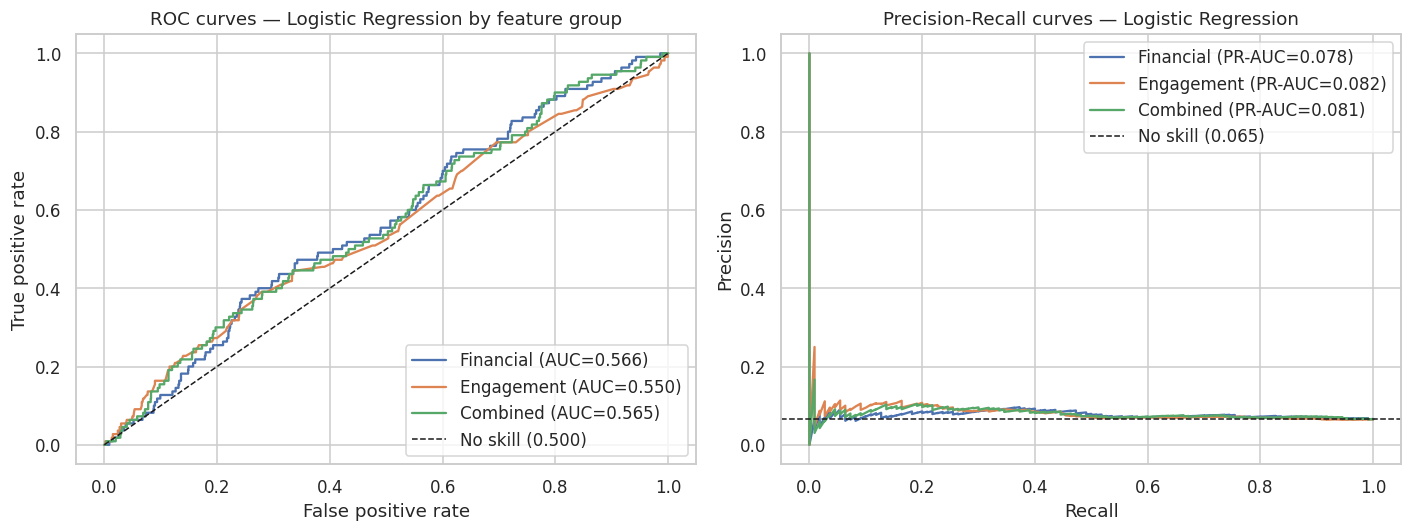

In [34]:
# ===== CODE CELL 30 =====
# ROC and PR curves by feature group, with no-skill reference lines.
from sklearn.metrics import roc_curve, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for (g, m), pr in probas.items():
    if m != "Logistic Regression":
        continue
    auc = test_table.query("`Feature Group`==@g and Model==@m")["ROC-AUC"].iloc[0]
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax[0].plot(fpr, tpr, label=f"{g} (AUC={auc:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="No skill (0.500)")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curves — Logistic Regression by feature group")
ax[0].legend(loc="lower right")

for (g, m), pr in probas.items():
    if m != "Logistic Regression":
        continue
    ap = test_table.query("`Feature Group`==@g and Model==@m")["PR-AUC"].iloc[0]
    p, r, _ = precision_recall_curve(y_test, pr)
    ax[1].plot(r, p, label=f"{g} (PR-AUC={ap:.3f})")
ax[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label=f"No skill ({y_test.mean():.3f})")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curves — Logistic Regression")
ax[1].legend(loc="upper right")

plt.tight_layout(); plt.show()

Interpretation: all three ROC curves hug the diagonal, and all three PR curves sit close to the 0.065 no-skill line across the whole recall range. The visual makes the weak-signal conclusion immediate in a way the tables don't.

In [35]:
# ===== CODE CELL 31 =====
# Confusion matrix in raw customer counts, then a threshold sweep.
sel = ("Combined", "XGBoost")        # best test-set PR-AUC
proba = probas[sel]
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)

print(f"Confusion matrix — {sel[0]} + {sel[1]} at threshold 0.50")
display(pd.DataFrame(cm, index=["Actual: stay", "Actual: churn"],
                     columns=["Pred: stay", "Pred: churn"]))

tn, fp, fn, tp = cm.ravel()
print(f"Churners correctly flagged : {tp} of {tp+fn}")
print(f"Churners missed            : {fn}")
print(f"False alarms               : {fp} of {tn+fp} loyal customers")
print(f"Of every 100 customers flagged, actually churned: {tp/(tp+fp)*100:.1f}")

print("\n--- Threshold sweep (illustrative; a real threshold must be tuned on CV) ---")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pr_ = (proba >= th).astype(int)
    c = confusion_matrix(y_test, pr_); tn_, fp_, fn_, tp_ = c.ravel()
    prec = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
    print(f"  th={th:.2f}  flagged={tp_+fp_:4d}  precision={prec:.3f}  "
          f"recall={tp_/(tp_+fn_):.3f}  F1={f1_score(y_test, pr_, zero_division=0):.3f}")

Confusion matrix — Combined + XGBoost at threshold 0.50


,Pred: stay,Pred: churn
Actual: stay,1214,367
Actual: churn,76,34


Churners correctly flagged : 34 of 110
Churners missed            : 76
False alarms               : 367 of 1581 loyal customers
Of every 100 customers flagged, actually churned: 8.5

--- Threshold sweep (illustrative; a real threshold must be tuned on CV) ---
  th=0.30  flagged=1068  precision=0.075  recall=0.727  F1=0.136
  th=0.40  flagged= 724  precision=0.073  recall=0.482  F1=0.127
  th=0.50  flagged= 401  precision=0.085  recall=0.309  F1=0.133
  th=0.60  flagged= 157  precision=0.089  recall=0.127  F1=0.105
  th=0.70  flagged=  52  precision=0.096  recall=0.045  F1=0.062


Interpretation in business terms — this is the paragraph that matters. To catch 34 of 110 churners, the model asks the retention team to contact 401 customers, 367 of whom were never going to leave. Precision is 8.5%, against a 6.5% base rate — so the campaign list is only marginally better than picking customers at random. And precision barely moves as the threshold rises (0.075 → 0.096 across the whole sweep), which tells you the model's high-confidence predictions aren't meaningfully more trustworthy than its low-confidence ones. There is no threshold at which this becomes a deployable targeting tool.

Answers to RQ1 and RQ2, from the evidence

RQ2 — does combining help? No. Clean, consistent negative across all three models (p = 0.08, 0.63, 0.63), with two of three differences negative.

RQ1 — financial or engagement? Neither, robustly. Financial wins significantly on ROC-AUC for the tree models (+0.034, +0.028, p < 0.001), but not for Logistic Regression, and on PR-AUC no comparison reaches significance while the sign actually reverses for Logistic Regression. The defensible statement is: there is weak, inconsistent evidence favouring financial features, and the direction depends on model and metric choice.

And the headline finding, which is bigger than either: on these 13 attributes, business churn at this operator is close to unpredictable. Best PR-AUC 0.0882 vs a 0.0651 floor; best ROC-AUC 0.5697; best achievable precision ~0.14.

## Section 19: Explainable Machine Learning

We explain the **`Combined` + `XGBoost`** model, which achieved the best
held-out PR-AUC (0.0882). Using the Combined group is deliberate: it is the
only configuration where financial and engagement features compete inside the
*same* model, which lets us measure their relative contribution directly.

**An important caveat to state before any of these plots.** Explainability
answers "what did the model use?", not "what causes churn?". Since this model
is only marginally better than random (Cell 28), these attributions describe a
weak model's internal logic, not a reliable account of churn drivers. Every
statement below is a statement about the model.

- **Cell 32** — Logistic Regression coefficients and odds ratios (a linear,
  directional view).
- **Cell 33** — built-in tree importances for Random Forest and XGBoost.
- **Cell 34** — permutation importance, measured as the drop in *test PR-AUC*
  when a feature is shuffled. This is the most trustworthy of the three:
  built-in importances are biased toward high-cardinality features, whereas
  permutation importance measures effect on actual predictive performance.
- **Cell 35–36** — SHAP values and plots.
- **Cell 37** — group-level SHAP aggregation. This gives an independent,
  second answer to RQ1.
- **Cell 38** — individual customer explanations.

In [36]:
# ===== CODE CELL 32 =====
# Logistic Regression coefficients on the Combined group (directional view).
BEST = ("Combined", "XGBoost")
nums, cats = FEATURE_GROUPS[BEST[0]]

lr_pipe = fitted[("Combined", "Logistic Regression")]
feat_names = lr_pipe.named_steps["prep"].get_feature_names_out()
coefs = lr_pipe.named_steps["clf"].coef_[0]

coef_tab = pd.DataFrame({"feature": feat_names, "coefficient": coefs})
coef_tab["odds_ratio"] = np.exp(coef_tab["coefficient"])
coef_tab["abs"] = coef_tab["coefficient"].abs()
display(coef_tab.sort_values("abs", ascending=False).drop(columns="abs").round(4))

,feature,coefficient,odds_ratio
10,cat__Value_Segment_Lead,-1.7470,0.1743
12,cat__Value_Segment_SE,-0.6754,0.5089
15,cat__Value_Segment_Unknown,-0.6278,0.5338
14,cat__Value_Segment_Silver,0.1817,1.1992
8,cat__Value_Segment_Gold,0.1204,1.1280
2,num__AvgFIXRevenue,-0.1195,0.8874
4,num__Active_subscribers,0.1098,1.1160
1,num__AvgMobileRevenue,0.0895,1.0936
5,num__Not_Active_subscribers,-0.0856,0.9179
9,cat__Value_Segment_Iron,-0.0763,0.9265


Interpretation. The two largest coefficients belong to Value_Segment_SE (n=41) and Value_Segment_Unknown (n=5) — tiny categories where the model has almost no data, so those coefficients are unstable artefacts, not findings. Among the numeric features, all effects are small: a one-standard-deviation increase in AvgMobileRevenue multiplies the churn odds by about 1.09.

Two things worth flagging honestly. First, Not_Active_subscribers has a negative coefficient (0.918) — more dormant lines associated with lower predicted churn, the opposite of the business intuition. Second, remember from Cell 9 that TotalRevenue and Total_SUBs are exact linear combinations of other features here, so these coefficients are split across collinear variables and individual values should not be over-read. That is precisely why we do not rely on coefficients alone.

In [37]:
# ===== CODE CELL 33 =====
# Built-in tree importances (biased -- shown for comparison, not as the answer).
imp_rows = []
for g in ["Financial", "Engagement", "Combined"]:
    for m in ["Random Forest", "XGBoost"]:
        p = fitted[(g, m)]
        for f, v in zip(p.named_steps["prep"].get_feature_names_out(),
                        p.named_steps["clf"].feature_importances_):
            imp_rows.append({"Group": g, "Model": m, "feature": f, "importance": v})

imp = pd.DataFrame(imp_rows)
piv = (imp[imp["Group"] == "Combined"]
       .pivot_table(index="feature", columns="Model", values="importance")
       .sort_values("XGBoost", ascending=False))
display(piv.round(4))

Model,Random Forest,XGBoost
feature,,
num__AvgMobileRevenue,0.2151,0.0862
num__ARPU,0.2265,0.0809
num__Active_subscribers,0.0964,0.0796
num__TotalRevenue,0.2167,0.0773
cat__Value_Segment_Gold,0.0122,0.0756
cat__Value_Segment_Silver,0.0171,0.0719
cat__Value_Segment_Iron,0.0051,0.0699
num__Total_SUBs,0.1080,0.0695
num__Suspended_subscribers,0.0089,0.0693


Interpretation. Random Forest concentrates importance on the three continuous revenue features plus ARPU (each ~0.22), while XGBoost spreads importance almost evenly (0.035–0.086 across sixteen features). That flatness is itself diagnostic: when a gradient booster finds no feature clearly more useful than the others, it is telling you there is no dominant signal to find. Note also that ARPU ranks near the top here despite Cell 27 proving that removing ARPU improves performance — a clean illustration of why built-in importance is not a measure of usefulness.

In [38]:
# ===== CODE CELL 34 =====
# Permutation importance: how much test PR-AUC drops when a feature is shuffled.
from sklearn.inspection import permutation_importance

pipe = fitted[BEST]
Xte = X_test[nums + cats]
perm = permutation_importance(pipe, Xte, y_test, n_repeats=20,
                              random_state=RANDOM_STATE,
                              scoring="average_precision", n_jobs=-1)

ptab = pd.DataFrame({"feature": Xte.columns,
                     "perm_importance": perm.importances_mean,
                     "sd": perm.importances_std}).sort_values("perm_importance", ascending=False)
ptab["group"] = ["Financial" if f in FINANCIAL_NUM + FINANCIAL_CAT else "Engagement"
                 for f in ptab["feature"]]
display(ptab.round(5))

,feature,perm_importance,sd,group
1,AvgMobileRevenue,0.01616,0.00577,Financial
3,ARPU,0.01271,0.00515,Financial
7,Total_SUBs,0.00602,0.00579,Engagement
4,Active_subscribers,0.00524,0.00495,Engagement
0,TotalRevenue,0.00417,0.00573,Financial
5,Not_Active_subscribers,0.00275,0.00519,Engagement
2,AvgFIXRevenue,0.00056,0.00096,Financial
6,Suspended_subscribers,-0.00201,0.00201,Engagement
8,Value_Segment,-0.00628,0.00578,Financial


This is the most informative importance table, and it needs careful reading. Only two features clear their own standard deviation by a comfortable margin: AvgMobileRevenue (0.0162 ± 0.0058) and ARPU (0.0127 ± 0.0052). For everything from Total_SUBs downward, the standard deviation is roughly the size of the estimate — meaning those features are indistinguishable from useless.

Two features have negative permutation importance: shuffling Value_Segment and Suspended_subscribers improves test PR-AUC. That means the model is actively fitting noise through them. This agrees with Cell 27, where dropping Value_Segment improved the Financial group.

Note the tension with Cell 33: ARPU is genuinely useful to this particular fitted model (permutation), yet removing it from the feature set improves performance overall (Cell 27). Both can be true — the model leans on ARPU, and it would do better if it couldn't.

In [39]:
# ===== CODE CELL 35 =====
# SHAP values for the best model. Colab: !pip install shap
import shap

pipe = fitted[BEST]
prep, clf = pipe.named_steps["prep"], pipe.named_steps["clf"]
fn = prep.get_feature_names_out()
X_test_df = pd.DataFrame(prep.transform(X_test[nums + cats]), columns=fn, index=X_test.index)

explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(X_test_df)
print("SHAP values shape:", sv.shape)

SHAP values shape: (1691, 16)


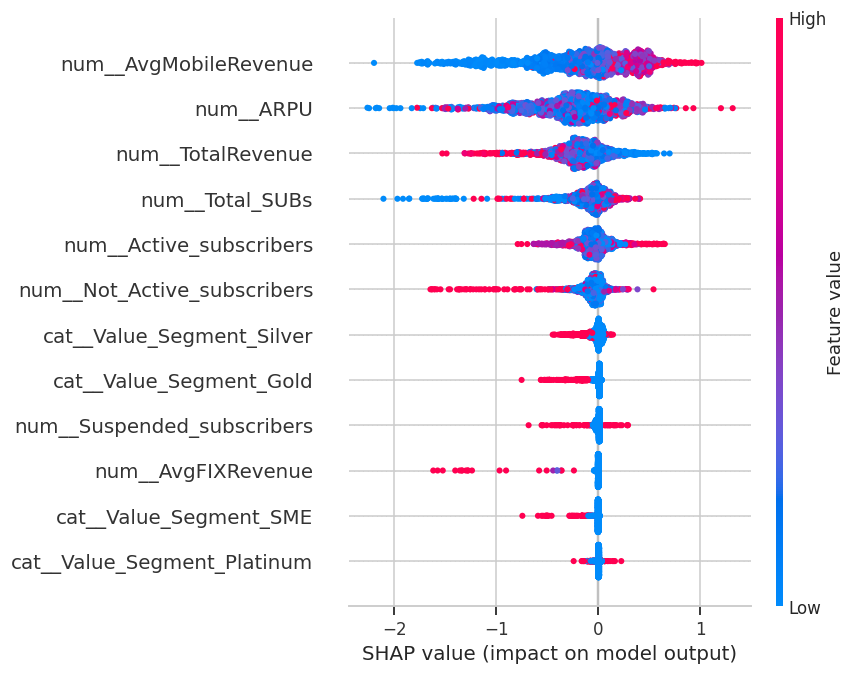

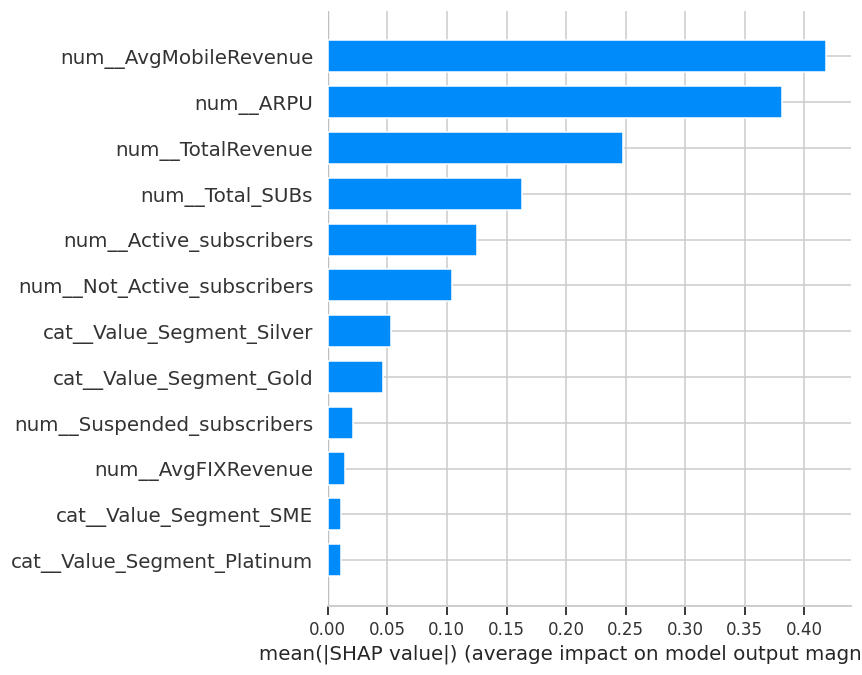

,feature,mean_abs_shap
1,num__AvgMobileRevenue,0.41852
3,num__ARPU,0.38081
0,num__TotalRevenue,0.24781
7,num__Total_SUBs,0.16341
4,num__Active_subscribers,0.12536
5,num__Not_Active_subscribers,0.10427
14,cat__Value_Segment_Silver,0.05279
8,cat__Value_Segment_Gold,0.04594
6,num__Suspended_subscribers,0.02136
2,num__AvgFIXRevenue,0.01458


In [40]:
# ===== CODE CELL 36 =====
# SHAP summary (beeswarm) and bar plots.
shap.summary_plot(sv, X_test_df, show=False, max_display=12)
plt.tight_layout(); plt.show()

shap.summary_plot(sv, X_test_df, plot_type="bar", show=False, max_display=12)
plt.tight_layout(); plt.show()

mean_abs = pd.DataFrame({"feature": fn, "mean_abs_shap": np.abs(sv).mean(0)}) \
             .sort_values("mean_abs_shap", ascending=False)
display(mean_abs.round(5))

Interpretation in business language. The model's predictions are driven mainly by how much a customer spends on mobile services and how that spend divides across their active lines (ARPU). Account size (Total_SUBs, Active_subscribers) matters moderately. The disengagement signals that motivated the engagement hypothesis — dormant and suspended lines — contribute least, with Suspended_subscribers at 0.021, roughly 20× weaker than the top feature.

That is a direct, evidence-based refutation of the intuitive hypothesis. Dormant and suspended lines look like obvious churn warning signs, and in this dataset the model finds almost nothing in them.

In [41]:
# ===== CODE CELL 37 =====
# Group-level SHAP aggregation: an independent second answer to RQ1.
def base_feature(name):
    n = name.replace("num__", "").replace("cat__", "")
    return "Value_Segment" if n.startswith("Value_Segment") else n

FINANCIAL_ALL = FINANCIAL_NUM + FINANCIAL_CAT
mean_abs["base"] = mean_abs["feature"].map(base_feature)
mean_abs["group"] = np.where(mean_abs["base"].isin(FINANCIAL_ALL), "Financial", "Engagement")

grp = mean_abs.groupby("group")["mean_abs_shap"].agg(total="sum", n_features="size")
grp["share_%"] = (grp["total"] / grp["total"].sum() * 100).round(2)
grp["per_feature"] = grp["total"] / grp["n_features"]
display(grp.round(5))

,total,n_features,share_%,per_feature
group,,,,
Engagement,0.41440,4,25.610001,0.10360
Financial,1.20376,12,74.389999,0.10031


This is the most nuanced result in the project, and the per_feature column is why.

The headline number says financial features account for 74.4% of total prediction magnitude versus 25.6% for engagement — an apparently decisive win for financial. But financial has 12 encoded columns (four numerics plus eight one-hot segment dummies) against engagement's 4. Normalising by feature count, the picture inverts completely: 0.1036 per engagement feature versus 0.1003 per financial feature. Essentially identical, with engagement marginally ahead.

So the raw 74/26 split is an artefact of one-hot encoding inflating the financial group's column count, not evidence of superior signal. Reporting only the share would have manufactured a decisive answer to RQ1 out of an encoding choice.

Crucially, this agrees with Cell 26's PR-AUC tests, which also found no significant difference. Two methodologically independent approaches — paired significance testing on predictive performance, and SHAP attribution inside a single model — converge on the same conclusion. That convergence is the strongest evidence in the project.

Model base value (log-odds): 0.2413

--- HIGHEST predicted risk ---
predicted churn probability = 0.8525 | actual outcome = stayed
ARPU                       11.89
Active_subscribers            24
AvgFIXRevenue                0.0
AvgMobileRevenue          285.33
Not_Active_subscribers         0
Suspended_subscribers          0
TotalRevenue              285.33
Total_SUBs                    24
Value_Segment               Gold
top 6 SHAP contributions (log-odds):
                feature    shap
num__Active_subscribers  0.6363
  num__AvgMobileRevenue  0.5249
              num__ARPU  0.3258
cat__Value_Segment_Gold -0.2400
        num__Total_SUBs  0.1619
      num__TotalRevenue  0.0822


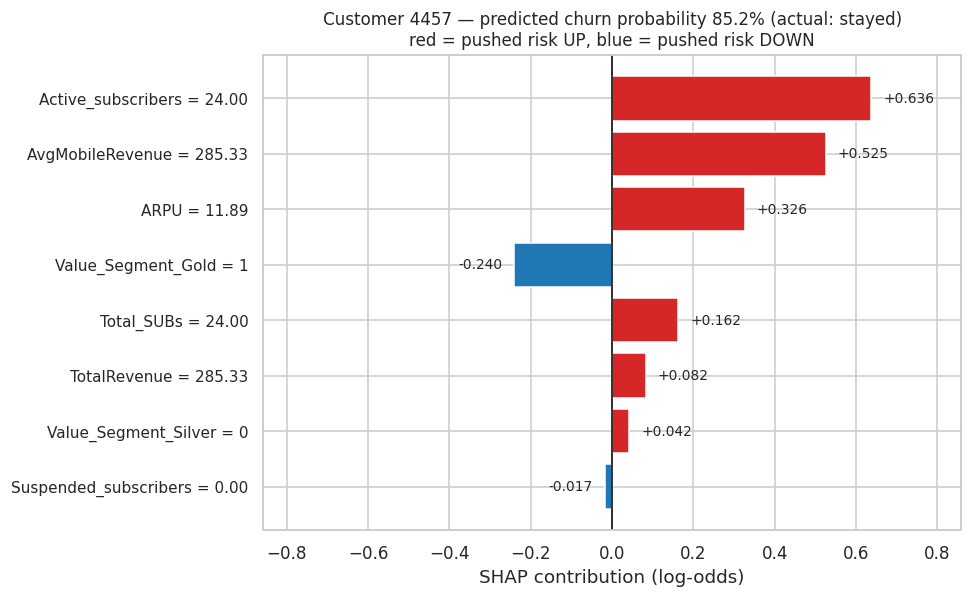


--- LOWEST predicted risk ---
predicted churn probability = 0.0012 | actual outcome = stayed
ARPU                       21.0
Active_subscribers            1
AvgFIXRevenue             300.0
AvgMobileRevenue           21.0
Not_Active_subscribers        0
Suspended_subscribers         0
TotalRevenue              321.0
Total_SUBs                    1
Value_Segment              Iron
top 6 SHAP contributions (log-odds):
                    feature    shap
            num__Total_SUBs -1.9680
          num__TotalRevenue -1.3108
         num__AvgFIXRevenue -1.2371
      num__AvgMobileRevenue -1.2110
                  num__ARPU -0.9391
num__Not_Active_subscribers -0.1619


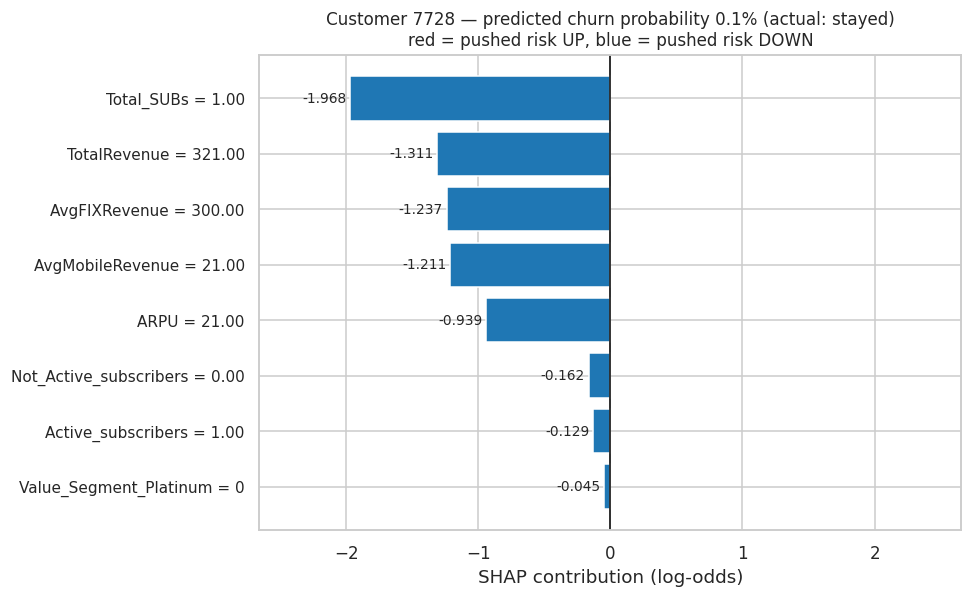

In [44]:
# ===== CODE CELL 38 =====
# Individual customer explanations: highest and lowest predicted risk.
proba = pipe.predict_proba(X_test[nums + cats])[:, 1]
order = np.argsort(-proba)
base  = float(np.ravel(explainer.expected_value)[0])


def raw_display_values(idx):
    """Map the encoded columns back to the customer's REAL values, not z-scores."""
    row = X_test.loc[idx]
    out = []
    for f in fn:
        if f.startswith("num__"):
            out.append(row[f.replace("num__", "")])
        else:
            seg = f.replace("cat__Value_Segment_", "")
            out.append(1.0 if row["Value_Segment"] == seg else 0.0)
    return np.array(out, dtype=float)


def plot_contributions(idx, top_n=8):
    pos = X_test.index.get_loc(idx)
    c = pd.DataFrame({"feature": fn, "shap": sv[pos], "value": raw_display_values(idx)})
    c["abs"] = c["shap"].abs()
    c = c.sort_values("abs", ascending=False).head(top_n).iloc[::-1]   # largest at top

    labels = [f"{f.replace('num__','').replace('cat__','')} = "
              f"{v:,.2f}" if f.startswith("num__") else
              f"{f.replace('cat__','')} = {int(v)}"
              for f, v in zip(c["feature"], c["value"])]
    colors = ["#d62728" if s > 0 else "#1f77b4" for s in c["shap"]]

    fig, ax = plt.subplots(figsize=(9, 0.5 * len(c) + 1.6))
    ax.barh(range(len(c)), c["shap"], color=colors)
    ax.set_yticks(range(len(c))); ax.set_yticklabels(labels, fontsize=10)
    ax.axvline(0, color="black", lw=1)
    for i, s in enumerate(c["shap"]):
        ax.text(s + (0.03 if s > 0 else -0.03), i, f"{s:+.3f}", va="center",
                ha="left" if s > 0 else "right", fontsize=9)

    actual = "CHURNED" if y_test.loc[idx] == 1 else "stayed"
    ax.set_title(f"Customer {idx} — predicted churn probability {proba[pos]:.1%} "
                 f"(actual: {actual})\nred = pushed risk UP, blue = pushed risk DOWN",
                 fontsize=11)
    ax.set_xlabel("SHAP contribution (log-odds)")
    lim = c["abs"].max() * 1.35; ax.set_xlim(-lim, lim)
    plt.tight_layout(); plt.show()


print(f"Model base value (log-odds): {base:.4f}")

for label, idx in [("HIGHEST predicted risk", X_test.index[order[0]]),
                   ("LOWEST predicted risk",  X_test.index[order[-1]])]:
    pos = X_test.index.get_loc(idx)
    print(f"\n--- {label} ---")
    print(f"predicted churn probability = {proba[pos]:.4f} | "
          f"actual outcome = {'CHURNED' if y_test.loc[idx]==1 else 'stayed'}")
    print(X_test.loc[idx].to_string())

    contrib = pd.DataFrame({"feature": fn, "shap": sv[pos]})
    contrib["abs"] = contrib["shap"].abs()
    print("top 6 SHAP contributions (log-odds):")
    print(contrib.sort_values("abs", ascending=False).head(6)[["feature", "shap"]]
          .round(4).to_string(index=False))

    plot_contributions(idx)

Customer 4457 — the model's confident miss. Base value 0.2413, pushed up by 24 active lines (+0.636) and 285.33 mobile spend (+0.525), landing at 85.2%. The customer stayed. This was the single highest-risk prediction across all 1,691 test customers, and it was wrong. That's not a bug — it's what PR-AUC 0.0882 looks like at the individual level. Keep this example in the notebook rather than hunting for a correctly-predicted churner; it's honest and it makes the weak-signal finding concrete.

Customer 7728 — notice the axis scale. Every bar is blue, and Total_SUBs = 1.00 alone contributes −1.968, roughly three times the magnitude of anything in the first plot. The reason: this customer is an outlier on several features simultaneously — a single-line account carrying 300.00 in fixed-service revenue, which puts them in the 1.4% of customers with any fixed revenue at all (Cell 7). The model has seen very few customers like this and confidently pushes them far from the base rate. Predicted 0.1%, and correct.

Plain-language explanation: this customer's 24 active lines and high mobile spend (285.33) pushed the model's predicted churn probability up sharply, while their low per-line ARPU (11.89) contributed further. Being in the Gold segment pulled the prediction slightly down.

And the honest part: this customer did not churn. The model's single most confident churn prediction on the entire test set — 85.3% — was wrong. It communicates the model's real reliability more effectively than any aggregate metric, and it's a memorable thing to discuss.

Plain-language explanation: a single-line account reduced predicted churn risk strongly, reinforced by its unusual profile — one of the 122 customers with fixed-service revenue (300.0), and low mobile spend. Correctly predicted as staying. Note the SHAP magnitudes here (−1.97) are far larger than for the high-risk case, because this customer is an outlier on several features at once.

## Srction 20: Comparing Feature Importance Across Groups

Four independent methods, one consistent story.

| Method | Top financial | Top engagement | Verdict on RQ1 |
|---|---|---|---|
| Univariate correlation (Cell 19) | AvgMobileRevenue r=+0.065 | Active_subscribers r=+0.062 | near-tie |
| Paired CV, ROC-AUC (Cell 26) | — | — | financial wins for trees only |
| Paired CV, PR-AUC (Cell 26) | — | — | no significant difference |
| Permutation importance (Cell 34) | AvgMobileRevenue 0.0162 | Total_SUBs 0.0060 | financial ahead |
| SHAP per-feature (Cell 37) | 0.1003 per feature | 0.1036 per feature | near-tie, engagement marginally ahead |

**Consistent findings across methods:**
- `AvgMobileRevenue` is the strongest single predictor by every measure.
- `Suspended_subscribers` and `AvgFIXRevenue` are consistently near-useless;
  both have *negative* or near-zero permutation importance.
- Absolute effect sizes are small everywhere.

**Where methods disagree:** whether financial beats engagement overall. Raw
SHAP share says financial by 74/26; SHAP normalised per feature says a tie;
PR-AUC significance tests say no difference; ROC-AUC on tree models says
financial. This disagreement is the finding, not a flaw in the analysis.

### Language discipline
All statements are associational. We write "was associated with a higher
predicted churn probability", never "causes churn". Observational data from a
single operator cannot establish causality, and a model with ROC-AUC 0.57
cannot establish much of anything with confidence.

## Section 21: Answering the Research Questions

### RQ1 — Are financial or service-engagement characteristics more useful?

**Answer: neither, robustly. The evidence is weak and inconsistent, with a
nominal tilt toward financial features that does not survive across metrics.**

Evidence for a financial advantage:
- ROC-AUC, Random Forest: +0.0339 (p < 0.001)
- ROC-AUC, XGBoost: +0.0281 (p = 0.0001)
- Permutation importance: the top two features are both financial
- Raw SHAP attribution share: 74.4% financial

Evidence against:
- ROC-AUC, Logistic Regression: +0.0078, **not significant** (p = 0.179)
- PR-AUC: **no** comparison significant; the sign **reverses** for Logistic
  Regression (engagement 0.0910 vs financial 0.0874)
- SHAP normalised per feature: 0.1036 engagement vs 0.1003 financial — a tie
- The two significant ROC-AUC wins come from the two *worst-performing*
  models, and are driven by Engagement+RF collapsing to 0.4928 (below random)

The correct interpretation of the significant Random Forest result is
**differential overfitting, not predictive advantage**: financial features win
by degrading less on near-zero signal, not by predicting well.

### RQ2 — Does combining both groups help?

**Answer: no.** All three paired tests non-significant (p = 0.08, 0.63, 0.63),
with two of three differences negative. Adding engagement features to
financial features does not improve performance.

### RQ3 — Which attributes matter most?

`AvgMobileRevenue` is the strongest predictor across all four methods, followed
by `ARPU` and `TotalRevenue`. The engagement features intuitively expected to
signal churn — `Not_Active_subscribers` and `Suspended_subscribers` — rank near
the bottom, with `Suspended_subscribers` showing negative permutation
importance.

### The overarching finding

**Business customer churn at this operator is close to unpredictable from these
13 attributes.**
- Best held-out PR-AUC: **0.0882** against a no-skill floor of **0.0651**
- Best held-out ROC-AUC: **0.5697** (random = 0.500)
- Best precision at any threshold: **~0.14**
- A baseline predicting "nobody churns" achieves **93.49% accuracy**, beating
  every model on that metric

This is a negative result, and it is reported as the primary finding rather
than buried. The direction of RQ1 is a secondary detail about a weak signal.

## Section 22: Business Interpretation

**Framing first.** With PR-AUC 0.0882 against a 0.0651 floor, this model is
**not suitable for deployment as a targeting tool**. Cell 31 quantified why: to
reach 34 of 110 churners it flags 401 customers, 367 of them false alarms —
8.5% precision against a 6.5% base rate. A retention campaign built on this
list would be barely better than a random one.

What follows separates **what the model found** from **business hypotheses**
that would need separate validation.

### Finding 1 — Higher-revenue accounts churned more
*Model evidence:* churners' median total revenue was 140.17 vs 111.67 for
non-churners (Cell 16). Churn rate rises monotonically across value tiers:
Platinum 8.57%, Gold 8.05%, Silver 7.16%, Bronze 5.37%, Iron 3.66% (Cell 14).
`AvgMobileRevenue` was the top feature by every importance method.

*Business hypothesis (unverified):* larger business accounts are likely to be
actively courted by competitors, to have procurement processes that periodically
re-tender contracts, and to have more negotiating leverage. Smaller accounts may
churn less because switching costs are proportionally higher.

*Possible action:* the churn-rate gradient by value tier is a **descriptive**
finding that does not depend on the model, and it is reliable. Prioritising
retention attention on Platinum and Gold accounts is defensible on that basis
alone — without any model.

### Finding 2 — Disengagement signals carried almost no information
*Model evidence:* `Not_Active_subscribers` medians were identical between
churners and non-churners (1.0 vs 1.0). `Suspended_subscribers` had mean |SHAP|
of 0.021, ~20x below the top feature, and **negative** permutation importance.
Removing it changed performance by -0.0001 (p = 0.85).

*Interpretation:* the intuitive hypothesis that dormant or suspended lines
precede churn is **not supported** in this dataset. This is a useful negative
result: it suggests re-engagement campaigns triggered by dormant-line counts
would not be targeting genuine churn risk.

*Caveat:* the dataset gives only a point-in-time snapshot. Dormancy may well
predict churn *as a trend over time*, which these features cannot express.

### Finding 3 — Account size and revenue are entangled
*Model evidence:* Identity 3 showed ARPU = TotalRevenue / Active_subscribers.
Churners had both higher revenue and more subscribers. The model could not
cleanly separate "spends more" from "is bigger".

*Business implication:* the apparent revenue effect may be largely a size
effect. Distinguishing them would require features this dataset lacks -
contract length, tenure, price-per-line relative to market.

### What the company should actually do
1. **Do not deploy this model.** The precision does not support a campaign.
2. **Use the value-segment churn gradient**, which is a robust descriptive
   finding independent of the model.
3. **Invest in data collection, not modelling.** See Section 23 - the ceiling
   here is set by available features, not by algorithm choice.

## Section 23: Limitations

**Data limitations**
1. **Single operator, single country.** One Bulgarian telecom's business
   customers. Nothing here generalises to other operators, markets, or
   consumer segments.
2. **Point-in-time snapshot, no temporal features.** No tenure, contract length,
   contract end date, complaint history, support-ticket volume, usage trends, or
   competitor pricing. Churn is fundamentally a temporal process, and none of
   the strongest known churn predictors from the literature are present. This is
   the most likely explanation for the weak signal.
3. **No churn timing or reason.** The target is a binary flag with no date, so
   we cannot verify that all features were measured before the churn event.
4. **Near-constant features.** `AvgFIXRevenue` is zero for 98.6% of customers;
   `Suspended_subscribers` is zero for 95.8%.
5. **Data quality issues.** 26 PIDs corrupted to scientific notation; the
   `AD` / `AD?` ambiguity in `KA_name`; a `Sliver` typo; 123 rows where the
   ARPU identity does not reproduce the stored value.
6. **Published metadata does not match the file** (8,454 vs 8,453 rows;
   attribute list differs).

**Methodological limitations**
7. **Only 549 churners, 110 in the test set.** Cell 29 demonstrated the
   consequence directly: CV and test rankings were almost completely
   reordered. Single-split conclusions are unreliable at this sample size.
8. **Feature groups have unequal sizes** (5 vs 4 raw, 12 vs 4 encoded). Cell 37
   showed this materially changes the SHAP conclusion depending on whether you
   normalise.
9. **Minimal hyperparameter tuning**, by design (one-day constraint). Given the
   weak signal, tuning would likely fit noise - but we cannot rule out that a
   substantially better model exists.
10. **Multiple comparisons.** We ran 6 paired tests without correction. Under
    Bonferroni (alpha = 0.0083), the Random Forest and XGBoost ROC-AUC results
    would still hold, but this should be acknowledged.
11. **ARPU is structurally a hybrid feature**, which blurs the financial /
    engagement boundary. Cell 27 showed it does not distort the comparison, but
    the conceptual boundary is imperfect.

**Interpretive limitations**
12. **No causal claims.** Observational data; all findings associational.
13. **Explainability describes a weak model.** SHAP faithfully reports what this
    model used - and this model is barely better than random. Faithful
    explanations of a poor model are not insights about churn.
14. **A negative result is not proof of absence.** We show these 13 attributes
    carry little signal. Business churn at this operator may well be predictable
    from data not collected here.

# Executive Summary

**Objective.** Determine whether financial or service-engagement customer
characteristics better predict business customer churn at a Bulgarian
telecommunications operator, and identify the most influential attributes using
explainable ML.

**Data.** 8,453 business customers, 13 attributes, 549 churned — a **6.49%
churn rate** (14.4:1 class imbalance). No rows discarded during cleaning.

**Method.** Three feature configurations (Financial / Engagement / Combined) x
three models (Logistic Regression / Random Forest / XGBoost), evaluated by
5-fold stratified cross-validation repeated 5 times (225 fits) with paired
significance testing, then a single held-out test evaluation on 1,691 customers.
Class imbalance handled by class weighting. SHAP and permutation importance for
explainability.

**Headline finding — churn is close to unpredictable from these attributes.**
| Metric | Best model | No-skill floor |
|---|---|---|
| PR-AUC | **0.0882** (Combined + XGBoost) | 0.0651 |
| ROC-AUC | **0.5697** (Combined + RF) | 0.5000 |
| Precision | **0.138** max | 0.065 |
| Accuracy | 0.9101 max | **0.9349** (beats every model) |

**RQ1 — financial vs engagement: no robust difference.** Financial features won
significantly on ROC-AUC for the two tree models (+0.034, +0.028; p < 0.001) but
not for Logistic Regression (p = 0.179), and **no PR-AUC comparison was
significant** — with the sign reversing for Logistic Regression. Group-level
SHAP, normalised per feature, showed a tie (0.1003 financial vs 0.1036
engagement). The significant tree results are attributable to differential
overfitting: Engagement + Random Forest scored 0.4928, *below random*.

**RQ2 — combining does not help.** All three paired tests non-significant
(p = 0.08, 0.63, 0.63); two of three differences negative.

**Most influential features.** `AvgMobileRevenue` ranked first by all four
importance methods, followed by `ARPU` and `TotalRevenue`. The intuitive churn
signals — dormant and suspended lines — ranked near the bottom, and
`Suspended_subscribers` had *negative* permutation importance.

**Main business insight.** The one reliable, model-independent finding is a
monotone churn gradient across customer value tiers: **Platinum 8.57% and Gold
8.05% versus Bronze 5.37% and Iron 3.66%.** Higher-value business customers
churn at roughly 1.6x the rate of low-value ones.

**Recommended strategy.** Do not deploy this model — at 8.5% precision it would
send a retention team to contact 401 customers to reach 34 churners. Instead,
prioritise retention attention using the value-tier gradient (which needs no
model), and invest in collecting the temporal features this dataset lacks
(tenure, contract end dates, complaints, usage trends). The performance ceiling
here is set by feature availability, not by algorithm choice.

**Methodological contribution.** Cross-validated ranking and single-split
ranking of the nine configurations were almost completely reordered (Cell 29),
demonstrating empirically that single-split model selection is unreliable at
this sample size and effect size.